## 미션11

기계 번역 실습으로, 한국어 문장을 영어로 번역하는 모델을 구축하는 프로젝트.

Seq2Seq 기본 모델, Attention 적용 모델을 구현하고 학습시키며, 각 모델의 성능을 비교 분석해보겠습니다.


### 가이드라인
- **데이터 전처리**
    - 적절한 토크나이저를 선택하여 한국어, 영어 문장을 토큰화하세요.
    - 문장 길이를 분석하여, 전체 문장의 길이에 맞게 최대 길이(MAX_LENGTH)를 설정하고, 필요한 경우 SOS, EOS, PAD, UNK 등의 특수 토큰을 정의합니다.

- **어휘 사전 구축**
    - 한국어와 영어 각각의 어휘 사전을 구성하세요.
    - 단어의 등장 빈도를 고려하여, 추후 임베딩이나 기타 모델 구성에 활용할 수 있습니다.

- **텐서 변환 및 데이터 로더 구현**
    - 각 문장을 토큰의 인덱스 시퀀스로 변환한 후, 고정 길이에 맞게 PAD 토큰으로 패딩합니다.
    - TensorDataset과 DataLoader를 활용하여 학습 데이터를 배치 단위로 효율적으로 처리할 수 있도록 구현하세요.


- **모델 구현 및 학습**
    - Seq2Seq 모델
        - 기본 GRU 기반의 Encoder-Decoder 모델을 구현하고, Teacher Forcing 기법을 적용해 학습합니다.
    - Attention 모델
        - Bahdanau Attention(Bahdanau 혹은 Luong)을 적용한 디코더를 구현하여, 번역 성능을 높여 보세요.

- **모델 학습 및 평가**
    - 각 모델별로 학습을 진행한 후, 평가 함수를 활용하여 번역 결과를 확인합니다.
    - 무작위 문장 쌍에 대해 모델의 번역 결과를 출력하고, 출력 문장을 정제(특수 토큰 제거 등)하여 성능을 분석해 보세요.

- **추가 실험**
    - 데이터 전처리 방법 개선(예: 불용어 제거, 정규화 등)
    - 모델 구조 변경(레이어 수, 은닉 상태 크기, Attention 기법 수정 등)
    - 하이퍼파라미터 튜닝(학습률, 배치 크기 등)
    - 다양한 평가 지표(예: BLEU 점수) 도입

In [ ]:
from google.colab import drive
import zipfile
import os

# 1. Google Drive 마운트
drive.mount('/content/drive')

In [ ]:
# 2.압축 파일 경로 설정
import os
zip_file_name = '일상생활및구어체_한영.zip'
zip_file_path = f'/content/drive/MyDrive/{zip_file_name}'

# 압축 해제할 경로
extract_path = './data'

# 폴더 없으면 생성
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# 3. 압축 해제
try:
    with zipfile.ZipFile(zip_file_path,'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"'{zip_file_path}' 파일이 '{extract_path}' 경로에 성공적으로 압축 해제되었습니다.")

    # 압축 해제된 파일 목록 확인
    print("\n압축 해제된 파일 목록:")
    for filename in os.listdir(extract_path):
        print(os.path.join(extract_path, filename))

except FileNotFoundError:
    print(f"오류: '{zip_file_path}' 파일을 찾을 수 없습니다.")
    print("Google Drive에 파일이 업로드되어 있는지 확인하세요.")

except Exception as e:
    print(f"오류: '{zip_file_path}' 파일의 압축 해제 중 문제가 발생했습니다.")

## 로컬에서 압축 제거

In [1]:
import os
import zipfile
import unicodedata

# 1.압축 파일 경로 설정
# Windows 한글 인코딩 정규화 문제 해결
zip_file_name = None

# 검색할 키워드를 NFC와 NFD 두 형식 모두 준비
search_keyword_nfc = unicodedata.normalize('NFC', '한영')
search_keyword_nfd = unicodedata.normalize('NFD', '한영')

for filename in os.listdir('.'):
    if filename.endswith('.zip'):
        # 파일명도 정규화해서 비교
        filename_nfc = unicodedata.normalize('NFC', filename)
        filename_nfd = unicodedata.normalize('NFD', filename)
        
        # NFC 또는 NFD 형식으로 매칭 확인
        if (search_keyword_nfc in filename_nfc or 
            search_keyword_nfd in filename_nfd or
            search_keyword_nfc in filename_nfd or
            search_keyword_nfd in filename_nfc):
            zip_file_name = filename  # 원본 파일명 사용
            print(f"✓ zip 파일 발견: '{zip_file_name}'")
            break

if zip_file_name is None:
    # 못 찾으면 .zip으로 끝나는 첫 번째 파일 사용
    for filename in os.listdir('.'):
        if filename.endswith('.zip'):
            zip_file_name = filename
            print(f"✓ zip 파일 자동 선택: '{zip_file_name}'")
            break

if zip_file_name is None:
    zip_file_name = '일상생활및구어체_한영.zip'
    print(f"⚠ 기본 파일명 사용: '{zip_file_name}'")

zip_file_path = zip_file_name

# 압축 해제할 경로
extract_path = './data'

# 폴더 없으면 생성
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# 2. 압축 해제
try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"\n✓ '{zip_file_path}' 파일이 '{extract_path}' 경로에 성공적으로 압축 해제되었습니다.")

    # 압축 해제된 파일 목록 확인
    print("\n압축 해제된 파일 목록:")
    for filename in os.listdir(extract_path):
        print(f"  - {os.path.join(extract_path, filename)}")

except FileNotFoundError:
    print(f"\n✗ 오류: '{zip_file_path}' 파일을 찾을 수 없습니다.")
    print("파일이 현재 디렉토리에 있는지 확인하세요.")

except Exception as e:
    print(f"\n✗ 오류: '{zip_file_path}' 파일의 압축 해제 중 문제가 발생했습니다.")
    print(f"상세 오류: {e}")

✓ zip 파일 발견: '일상생활및구어체_한영.zip'

✓ '일상생활및구어체_한영.zip' 파일이 './data' 경로에 성공적으로 압축 해제되었습니다.

압축 해제된 파일 목록:
  - ./data\일상생활및구어체_한영_train_set.json
  - ./data\일상생활및구어체_한영_valid_set.json


파일을 압축 해제하였으니 파일 구조를 살펴보겠습니다.

- 훈련 데이터 로드 및 구조 확인: 훈련 데이터 파일 './data/일상생활및구어체_한영_train_set.json'을 로드하여 데이터의 구조(예: 키, 값의 형태, 첫 몇 개 엔트리)를 확인합니다.

- 검증 데이터 로드 및 구조 확인: 검증 데이터 파일 './data/일상생활및구어체_한영_valid_set.json'을 로드하여 데이터의 구조(예: 키, 값의 형태, 첫 몇 개 엔트리)를 확인합니다. 훈련 데이터와 구조가 동일한지 비교합니다.

- 데이터 전처리 계획 수립: 로드된 데이터의 구조와 미션 가이드라인(토크나이저 선택, 최대 길이 설정, 특수 토큰 정의, 어휘 사전 구축, 텐서 변환 및 패딩, DataLoader 구현)을 기반으로 상세한 데이터 전처리 계획을 수립합니다.

- Final Task: JSON 파일의 구조 확인 결과와 이에 기반한 데이터 전처리 계획을 요약하여 제시합니다

## 훈련 데이터 로드 및 구조 확인

### Subtask:
훈련 데이터 파일 './data/일상생활및구어체_한영_train_set.json'을 로드하여 데이터의 구조(예: 키, 값의 형태, 첫 몇 개 엔트리)를 확인합니다.

학습 데이터의 구조를 이해하기 위해 JSON 파일을 불러와 최상위 키를 출력하고 처음 몇 개의 항목을 살펴보겠습니다.


In [1]:
import json

# 1. 학습 데이터의 파일 경로를 정의
train_file_path = './data/일상생활및구어체_한영_train_set.json'

# 2. 학습 데이터 JSON 파일을 열고 내용을 불러옵니다.
with open(train_file_path, 'r', encoding='utf-8') as f:
    train_data = json.load(f)

print(f"{train_file_path} 에서 학습 데이터를 성공적으로 불러왔습니다.")

# 3. train_data 딕셔너리의 키를 출력하여 최상위 구조를 파악합니다.
print("\ntrain_data 의 Key:")
print(train_data.keys())

./data/일상생활및구어체_한영_train_set.json 에서 학습 데이터를 성공적으로 불러왔습니다.

train_data 의 Key:
dict_keys(['data'])


In [2]:
# 4. Train_data 처음 5개 항목 출력
print("\ntrain_data:")
for i, item in enumerate(train_data['data'][:5]):
  print(i, ": ", item)


train_data:
0 :  {'sn': 'INTSALDSUT062119042703238', 'data_set': '일상생활및구어체', 'domain': '해외영업', 'subdomain': '도소매유통', 'ko_original': '원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.', 'ko': '원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.', 'mt': 'If you reply to the color you want, we will start making it right away.', 'en': 'If you reply to the color you want, we will start making it right away.', 'source_language': 'ko', 'target_language': 'en', 'word_count_ko': 7, 'word_count_en': 15, 'word_ratio': 2.143, 'file_name': 'INTSAL_DSUT.xlsx', 'source': '크라우드소싱', 'license': 'open', 'style': '구어체', 'included_unknown_words': False, 'ner': None}
1 :  {'sn': 'KTOS062012215152657', 'data_set': '일상생활및구어체', 'domain': '일상생활', 'subdomain': '여행', 'ko_original': '형님 제일 웃긴 그림이 뭔지 알아요.', 'ko': '형님 제일 웃긴 그림이 뭔지 알아요.', 'mt': 'I know what the funniest picture is.', 'en': 'You know what the funniest picture is.', 'source_language': 'ko', 'target_language': 'en', 'word_count_ko': 6, 'word_count_en': 7, 'word_ratio': 1.167, 'file_name': 

번역 모델은 (입력, 출력) 문장 쌍이 필요합니다.

이 데이터를 확인해보니 'ko' -> 입력

'mt' -> 출력으로 리스트를 만들어보아야겠습니다.

In [3]:
# 학습 전용 쌍
pairs = [(item['ko'] , item['en']) for item in train_data['data']]
pairs[:10]

[('원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.',
  'If you reply to the color you want, we will start making it right away.'),
 ('형님 제일 웃긴 그림이 뭔지 알아요.', 'You know what the funniest picture is.'),
 ('>속옷을?', '>Underwear?'),
 ('그래도 가격이 꽤 비싸니까 많이 살게요.',
  'I wont buy a lot though since the price is still quite high.'),
 ('AAA님, 제가 회의에서 화를 냈던 점 정말 사과드리고 싶습니다.',
  'Dear AAA, I really want to apologize for my anger at the meeting.'),
 ('>회식하거든.', ">We're having a get-together."),
 ('돈은 어디에 투자하셨나요?', 'Where did you invest the money?'),
 ('예 이게 빅데이터 빅이네요.', 'Yes, the is big data is big.'),
 ('따라서 부동산 소유자는 종종 비어 있는 값비싼 부동산을 남게 됩니다.',
  'Real estate owners are therefore left with expensive estates which are often vacant.'),
 ('귀사와의 계약을 취소함에 대해 죄송하게 생각하며, 이에 대한 양해를 구합니다.',
  'We apologize for canceling the contract with your company and ask for your understanding.')]

`>` 같은 노이즈가 있는 걸 확인하였습니다.

전처리단계에서 노이즈를 지워보겠습니다.

하지만 물음표, 느낌표, 마침점은 번역 해석에서 중요한 부분이기 때문에

노이즈 기호는 `>` 는 val 데이터도 있는지 확인해보겠습니다.

In [1]:
def count_symbol(data, key, symbol):
    return sum(symbol in item[key] for item in data)

In [2]:
import json

train_file_path = './data/일상생활및구어체_한영_train_set.json'
valid_file_path = './data/일상생활및구어체_한영_valid_set.json'

with open(train_file_path, 'r', encoding='utf-8') as f:
    train_data = json.load(f)

with open(valid_file_path, 'r', encoding='utf-8') as f:
    valid_data = json.load(f)

train_cnt = count_symbol(train_data["data"], "ko", ">")
val_cnt   = count_symbol(valid_data["data"], "ko", ">")

print(train_cnt, val_cnt)

282515 35211


train , val 둘다 꽤나 자주 나오는걸 확인하였고 `>` 을 제거 하는 함수를 작성하겠습니다.


In [3]:
def clean_sentence(sentence):
  sentence = sentence.replace('>','')
  return sentence.strip()

In [6]:
pairs = [(clean_sentence(item['ko']), clean_sentence(item['en']))
    for item in train_data['data']]

pairs[:10]

[('원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.',
  'If you reply to the color you want, we will start making it right away.'),
 ('형님 제일 웃긴 그림이 뭔지 알아요.', 'You know what the funniest picture is.'),
 ('속옷을?', 'Underwear?'),
 ('그래도 가격이 꽤 비싸니까 많이 살게요.',
  'I wont buy a lot though since the price is still quite high.'),
 ('AAA님, 제가 회의에서 화를 냈던 점 정말 사과드리고 싶습니다.',
  'Dear AAA, I really want to apologize for my anger at the meeting.'),
 ('회식하거든.', "We're having a get-together."),
 ('돈은 어디에 투자하셨나요?', 'Where did you invest the money?'),
 ('예 이게 빅데이터 빅이네요.', 'Yes, the is big data is big.'),
 ('따라서 부동산 소유자는 종종 비어 있는 값비싼 부동산을 남게 됩니다.',
  'Real estate owners are therefore left with expensive estates which are often vacant.'),
 ('귀사와의 계약을 취소함에 대해 죄송하게 생각하며, 이에 대한 양해를 구합니다.',
  'We apologize for canceling the contract with your company and ask for your understanding.')]

#### 토크나이저 선택

Seq2Seq / Attention 구조 이해가 목적이기에

- 한국어: 공백 기반 토크나이징

- 영어: 공백 + 소`문자

로 토크나이저 해보겠습니다.

그리고 허깅페이스 실습을 위해서
`facebook/mbart-large-50-many-to-many-mmt` 로도 실습해보겠습니다.

In [4]:
# 토크나이저 선택
# 한국어, 영어 따로 진행
import re

def tokenize_ko(sentence):
  # 구두점 앞뒤에 공백 추가 후 spl`it
  sentence = re.sub(r'([?.!,])', r' \1',sentence)
  return sentence.split()

def tokenize_en(sentence):
  # 구두점 분리 + 소문자 변환
  sentence = re.sub(r'([?.!,])',r' \1', sentence)
  sentence = sentence.lower()
  return sentence.split()


In [36]:
pairs = [(tokenize_ko(item['ko']), tokenize_en(item['en']))
    for ko, en in pairs]
# 똑같은 문장만 복사되어 오류
pairs[:10]

[(['AAA님', ',', '제가', '회의에서', '화를', '냈던', '점', '정말', '사과드리고', '싶습니다', '.'],
  ['dear',
   'aaa',
   ',',
   'i',
   'really',
   'want',
   'to',
   'apologize',
   'for',
   'my',
   'anger',
   'at',
   'the',
   'meeting',
   '.']),
 (['AAA님', ',', '제가', '회의에서', '화를', '냈던', '점', '정말', '사과드리고', '싶습니다', '.'],
  ['dear',
   'aaa',
   ',',
   'i',
   'really',
   'want',
   'to',
   'apologize',
   'for',
   'my',
   'anger',
   'at',
   'the',
   'meeting',
   '.']),
 (['AAA님', ',', '제가', '회의에서', '화를', '냈던', '점', '정말', '사과드리고', '싶습니다', '.'],
  ['dear',
   'aaa',
   ',',
   'i',
   'really',
   'want',
   'to',
   'apologize',
   'for',
   'my',
   'anger',
   'at',
   'the',
   'meeting',
   '.']),
 (['AAA님', ',', '제가', '회의에서', '화를', '냈던', '점', '정말', '사과드리고', '싶습니다', '.'],
  ['dear',
   'aaa',
   ',',
   'i',
   'really',
   'want',
   'to',
   'apologize',
   'for',
   'my',
   'anger',
   'at',
   'the',
   'meeting',
   '.']),
 (['AAA님', ',', '제가', '회의에서', '화를', '냈던', '점', '정말', '사과

앞에 셀에서 문제가 되었으나 나중에 확인하려 아래에 다시 정상 작동 코드 구현하였습니다.

In [8]:
pairs = [(tokenize_ko(ko), tokenize_en(en))
         for ko, en in pairs]

pairs[:10]

[(['원하시는', '색상을', '회신해', '주시면', '바로', '제작', '들어가겠습니다', '.'],
  ['if',
   'you',
   'reply',
   'to',
   'the',
   'color',
   'you',
   'want',
   ',',
   'we',
   'will',
   'start',
   'making',
   'it',
   'right',
   'away',
   '.']),
 (['형님', '제일', '웃긴', '그림이', '뭔지', '알아요', '.'],
  ['you', 'know', 'what', 'the', 'funniest', 'picture', 'is', '.']),
 (['속옷을', '?'], ['underwear', '?']),
 (['그래도', '가격이', '꽤', '비싸니까', '많이', '살게요', '.'],
  ['i',
   'wont',
   'buy',
   'a',
   'lot',
   'though',
   'since',
   'the',
   'price',
   'is',
   'still',
   'quite',
   'high',
   '.']),
 (['AAA님', ',', '제가', '회의에서', '화를', '냈던', '점', '정말', '사과드리고', '싶습니다', '.'],
  ['dear',
   'aaa',
   ',',
   'i',
   'really',
   'want',
   'to',
   'apologize',
   'for',
   'my',
   'anger',
   'at',
   'the',
   'meeting',
   '.']),
 (['회식하거든', '.'], ["we're", 'having', 'a', 'get-together', '.']),
 (['돈은', '어디에', '투자하셨나요', '?'],
  ['where', 'did', 'you', 'invest', 'the', 'money', '?']),
 (['예', '이게', '빅데이

구두점과 소문자 변환이 잘 되어있음을 확인하였습니다.

#### 문장 길이 분석하겠습니다.

In [9]:
# 1. 문장 길이 분석
ko_lengths = []
en_lengths = []

ko_lengths = [len(ko) for ko in pairs]
en_lengths = [len(en) for en in pairs]

# 2. 통계 확인
import numpy as np
print(f"한국어 평균 길이: {np.mean(ko_lengths):.2f}, 최대 길이: {np.max(ko_lengths)}, 최소 길이: {np.min(ko_lengths):.2f}")
print(f"한국어 최대 길이: {np.max(ko_lengths)}")
print(f"한국어 95% 길이: {np.percentile(ko_lengths,95)}")

print(f"\n영어 평균 길이: {np.mean(en_lengths):.2f}, 최대 길이: {np.max(en_lengths)}, 최소 길이: {np.min(en_lengths):.2f}")
print(f"영어 최대 길이: {np.max(en_lengths)}")
print(f"영어 95% 길이: {np.percentile(en_lengths,95)}")

한국어 평균 길이: 2.00, 최대 길이: 2, 최소 길이: 2.00
한국어 최대 길이: 2
한국어 95% 길이: 2.0

영어 평균 길이: 2.00, 최대 길이: 2, 최소 길이: 2.00
영어 최대 길이: 2
영어 95% 길이: 2.0


In [5]:
import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
def set_korean_font():
    """Windows/Mac/Linux 모두에서 작동하는 한글 폰트 설정"""
    system = platform.system()
    
    # 1. 시스템별 폰트 후보 목록
    if system == 'Darwin':  # macOS
        fonts = ['AppleGothic', 'AppleMyungjo']
    elif system == 'Windows':  # Windows
        fonts = ['Malgun Gothic', 'MalgunGothic', 'NanumGothic', 
                          'Gulim', 'Batang', 'Dotum']
    else:  # Linux
        fonts = ['NanumGothic', 'NanumBarunGothic', 'DejaVu Sans']
    
    # 사용 가능한 폰트 찾기
    available_fonts = [font.name for font in fm.fontManager.ttflist]
    
    for font in fonts:
        if font in available_fonts:
            plt.rc('font', family=font)
            print(f"설정된 폰트: {font}")
            break
    else:
        print("한글 폰트를 찾을 수 없습니다. 기본 폰트 사용")
    
    # 마이너스 기호 깨짐 방지
    plt.rc('axes', unicode_minus=False)

전체 pairs 개수: 1200000
ko_lengths 개수: 1200000

첫 20개 문장 길이:
[8, 7, 2, 7, 11, 2, 4, 5, 11, 12, 4, 13, 7, 9, 9, 9, 12, 5, 8, 7]
[17, 8, 2, 14, 15, 5, 7, 9, 14, 15, 6, 20, 12, 14, 16, 19, 17, 7, 7, 13]
설정된 폰트: Malgun Gothic


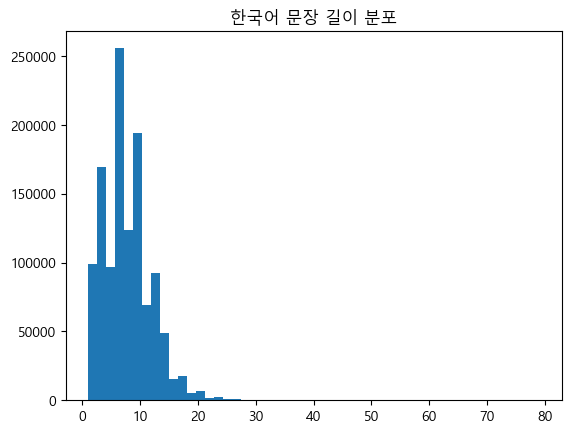

In [13]:
# 데이터 개수 확인
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

print(f"전체 pairs 개수: {len(pairs)}")
print(f"ko_lengths 개수: {len(ko_lengths)}")

# 실제 길이 분포 확인
print(f"\n첫 20개 문장 길이:")
print(ko_lengths[:20])
print(en_lengths[:20])

# 히스토그램
plt.hist(ko_lengths, bins=50)

set_korean_font()
plt.title('한국어 문장 길이 분포')

plt.show()

In [13]:
# 3. MAX_LENGTH 설정
MAX_LENGTH = {
    "ko": int(np.percentile(ko_lengths, 95)),
    "en": int(np.percentile(en_lengths, 95))
}

print("MAX_LENGTH:", MAX_LENGTH)

MAX_LENGTH: {'ko': 55, 'en': 117}


리스트 컴프리헨션에서 루프 변수를 잘 못 사용해서 오류가 나왔으나 수정하였습니다.

### 특수 토큰 정의 & 어휘 사전 구축

시작하겠습니다.

In [6]:
# 4. 특수 토큰 정의
SOS_TOKEN = 0 # Start of Sentence
EOS_TOKEN = 1 # End of Sentence
PAD_TOKEN = 2 # Padding Token
UNK_TOKEN = 3 # Unknown Token

print("특수 토큰이 정의되었습니다.")
print("SOS_TOKEN:", SOS_TOKEN)
print("EOS_TOKEN:", EOS_TOKEN)
print("PAD_TOKEN:", PAD_TOKEN)
print("UNK_TOKEN:", UNK_TOKEN)

특수 토큰이 정의되었습니다.
SOS_TOKEN: 0
EOS_TOKEN: 1
PAD_TOKEN: 2
UNK_TOKEN: 3


In [7]:
# 5. 어휘 사전 구축
class Vocab:
    def __init__(self):
        self.word2idx = {"<PAD>":PAD_TOKEN, "<SOS>":SOS_TOKEN,
                         "<EOS>":EOS_TOKEN, "<UNK>":UNK_TOKEN}
        self.idx2word = {PAD_TOKEN:"<PAD>", SOS_TOKEN:"<SOS>",
                         EOS_TOKEN:"<EOS>", UNK_TOKEN:"<UNK>"}
        self.word2count = {}
        self.n_words = 4 # 특수 토큰 개수
        
    def add_sentence(self, sentence):
        """
        문장(토큰 리스트)을 받아서 어휘 사전에 추가
        """
        for word in sentence:
            self.add_word(word)
            
    def add_word(self, word):
        """
        단어를 어휘에 추가
        """
        if word not in self.word2idx:
            self.word2idx[word] = self.n_words
            self.idx2word[self.n_words] = word
            self.word2count[word] = 1
            self.n_words += 1
        else:
            self.word2count[word]+= 1

In [13]:
 # 한국어, 영어 어휘 사전 생성
ko_vocab = Vocab()
en_vocab = Vocab()

# pairs에서 어휘 추가
for ko_tokens, en_tokens in pairs:
    ko_vocab.add_sentence(ko_tokens)
    en_vocab.add_sentence(en_tokens)

print(f"한국어 어휘 사전 크기: {ko_vocab.n_words}")
print(f"영어 어휘 사전 크기: {en_vocab.n_words}")

한국어 어휘 사전 크기: 533431
영어 어휘 사전 크기: 81910


In [15]:
# 한국어 어휘 사전 확인 (처음 10개 단어-인덱스 쌍)
print("=== 한국어 어휘 사전 (word2idx) ===")
ko_items = list(ko_vocab.word2idx.items())[4:14]
print(ko_items)

print("\n=== 한국어 어휘 사전 (idx2word) ===")
ko_items = list(ko_vocab.idx2word.items())[4:14]
print(ko_items)

# 영어 어휘 사전 확인 (처음 10개 단어-인덱스 쌍)
print("\n=== 영어 어휘 사전 (word2idx) ===")
en_items = list(en_vocab.word2idx.items())[4:14]
print(en_items)

print("\n=== 영어 어휘 사전 (idx2word) ===")
en_items = list(en_vocab.idx2word.items())[4:14]
print(en_items)

# 가장 자주 등장하는 한국어 단어 10개
from collections import Counter
ko_most_common = Counter(ko_vocab.word2count).most_common(10)
print("\n=== 한국어 가장 자주 등장하는 단어 10개 ===")
print(ko_most_common)

# 가장 자주 등장하는 영어 단어 10개
en_most_common = Counter(en_vocab.word2count).most_common(10)
print("\n=== 영어 가장 자주 등장하는 단어 10개 ===")
print(en_most_common)

=== 한국어 어휘 사전 (word2idx) ===
[('원하시는', 4), ('색상을', 5), ('회신해', 6), ('주시면', 7), ('바로', 8), ('제작', 9), ('들어가겠습니다', 10), ('.', 11), ('형님', 12), ('제일', 13)]

=== 한국어 어휘 사전 (idx2word) ===
[(4, '원하시는'), (5, '색상을'), (6, '회신해'), (7, '주시면'), (8, '바로'), (9, '제작'), (10, '들어가겠습니다'), (11, '.'), (12, '형님'), (13, '제일')]

=== 영어 어휘 사전 (word2idx) ===
[('if', 4), ('you', 5), ('reply', 6), ('to', 7), ('the', 8), ('color', 9), ('want', 10), (',', 11), ('we', 12), ('will', 13)]

=== 영어 어휘 사전 (idx2word) ===
[(4, 'if'), (5, 'you'), (6, 'reply'), (7, 'to'), (8, 'the'), (9, 'color'), (10, 'want'), (11, ','), (12, 'we'), (13, 'will')]

=== 한국어 가장 자주 등장하는 단어 10개 ===
[('.', 1054334), (',', 277072), ('?', 133941), ('수', 101991), ('있습니다', 98638), ('저희', 43139), ('이', 41804), ('있는', 33423), ('네', 32363), ('합니다', 27192)]

=== 영어 가장 자주 등장하는 단어 10개 ===
[('.', 1068677), (',', 552956), ('the', 551647), ('to', 343575), ('you', 307903), ('a', 274841), ('and', 234272), ('i', 227924), ('it', 212103), ('is', 206966)]


의문점이 들었습니다. 기계 학습에서 불용어를 지우지 않아야 할까요?

확인 결과

- 불용어를 제거 하면 언어 모델 자체가 성립하지 않습니다.

`ko : 나는 학교에 간다`

`en : I am going to school`

불용어 제거 시

`going school`

문법이 붕괴됩니다.

의미 없는 특수 기호만 제한적으로 제거하고<br/> 다음 과정으로 넘어가겠습니다.

In [8]:
# 6.문장을 인덱스 시퀀스로 변환

def sentence_to_indices(vocab, sentence):
    """
    문장(토큰 리스트)을 받아서 인덱스 리스트로 변환
    sentence(list): 토큰 리스트
    """
    indexes = [vocab.word2idx.get(word, UNK_TOKEN) for word in sentence]
    indexes.append(EOS_TOKEN) # EOS 토큰 추가
    return indexes

In [15]:
sentence_ko , sentence_en = pairs[73]
ko_indexes = sentence_to_indices(ko_vocab, sentence_ko)
en_indexes = sentence_to_indices(en_vocab, sentence_en)

print(f"한국어 문장 :{' '.join(sentence_ko)}")
print(f"\n한국어 인덱스 :{ko_indexes}")
print(f"\n영어 문장 :{' '.join(sentence_en)}")
print(f"\n영어 인덱스 :{en_indexes}")

한국어 문장 :최 상 의   품 질 을   위 해 서   씨 앗   키 트 를   재 배 기 에   투 입 한   후   엽 채 류 는   4 주   이 후 ,   허 브 류 는   6 주   이 후 ,   화 훼 류 는   8 주   이 후 에   일 괄   수 확 하 는   것 을   추 천 합 니 다 .

한국어 인덱스 :[300, 10, 57, 8, 157, 316, 11, 8, 171, 14, 59, 8, 360, 361, 8, 252, 126, 61, 8, 349, 123, 177, 58, 8, 79, 199, 113, 8, 208, 8, 120, 184, 362, 7, 8, 287, 15, 8, 36, 208, 56, 8, 363, 364, 362, 7, 8, 365, 15, 8, 36, 208, 56, 8, 60, 366, 362, 7, 8, 367, 15, 8, 36, 208, 58, 8, 31, 368, 8, 164, 369, 5, 7, 8, 344, 11, 8, 196, 197, 116, 26, 27, 28, 1]

영어 문장 :F o r   t h e   b e s t   q u a l i t y ,   i t   i s   r e c o m m e n d e d   t o   c o l l e c t i v e l y   h a r v e s t   l e a f   v e g e t a b l e s   a f t e r   4   w e e k s ,   h e r b s   a f t e r   6   w e e k s ,   a n d   f l o w e r s   a f t e r   8   w e e k s   a f t e r   p u t t i n g   s e e d   k i t s   i n t o   t h e   c u l t i v a t o r .

영어 인덱스 :[50, 8, 10, 6, 14, 15, 11, 6, 31, 11, 22, 14, 6, 32, 9, 18, 13, 21, 14, 7, 20, 6,

In [9]:
# 7. 패딩 함수

def pad_sequence(indexes, max_length, pad_token=PAD_TOKEN):
    """
    인덱스 시퀀스를 max_length에 맞게 패딩하거나 자르기
    """
    if len(indexes) < max_length:
        # 패딩 추가
        indexes = indexes + [pad_token] * (max_length - len(indexes))
    else:
        # 자르기
        indexes = indexes[:max_length]
    return indexes
    

In [16]:
padded_ko = pad_sequence(ko_indexes, MAX_LENGTH['ko'])
padded_en = pad_sequence(en_indexes, MAX_LENGTH['en'])

print(f"패딩 전 한국어 길이 :{len(ko_indexes)}, 패딩 후 한국어 길이: {len(padded_ko)}")
print(f"패딩 전 영어 길이 :{len(en_indexes)}, 패딩 후 영어 길이: {len(padded_en)}")

패딩 전 한국어 길이 :84, 패딩 후 한국어 길이: 55
패딩 전 영어 길이 :187, 패딩 후 영어 길이: 117


In [ ]:
# 8. 데이터 분리 (Train/Val/Test)
# 데이터 구성
# train_data      → train_loader  (80%)
# valid_data      → val_loader (5%) + test_loader (5%)
#                 └─ valid_data 를 반반 나눌 예정
# ko_tensors, en_tensors를 train/val/test로 분리

import random
import numpy as np
import torch

# 1. 랜덤 시드 고정 (재현성 보장)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    
# ============================================
# 1. Train pairs 생성 (전체 train_data 사용)
# ============================================

train_pairs = []
for item in train_data['data']:
    ko_cleaned = clean_sentence(item['ko'])
    en_cleaned = clean_sentence(item['en'])
    
    ko_tokenized = tokenize_ko(ko_cleaned)
    en_tokenized = tokenize_en(en_cleaned)
    
    train_pairs.append((ko_tokenized, en_tokenized))

print(f"Train pairs: {len(train_pairs)}")

# ============================================
# 2. Valid data를 Val/Test로 분리 (50:50)
# ============================================

# Valid 데이터를 섞음
valid_data_shuffled = valid_data['data'].copy()
random.shuffle(valid_data_shuffled)

# 반반 나눔
split_idx = len(valid_data_shuffled) // 2

val_raw = valid_data_shuffled[:split_idx]
test_raw = valid_data_shuffled[split_idx:]

# Val pairs 생성
val_pairs = []
for item in val_raw:
    ko_cleaned = clean_sentence(item['ko'])
    en_cleaned = clean_sentence(item['en'])
    
    ko_tokenized = tokenize_ko(ko_cleaned)
    en_tokenized = tokenize_en(en_cleaned)
    
    val_pairs.append((ko_tokenized, en_tokenized))

# Test pairs 생성
test_pairs = []
for item in test_raw:
    ko_cleaned = clean_sentence(item['ko'])
    en_cleaned = clean_sentence(item['en'])
    
    ko_tokenized = tokenize_ko(ko_cleaned)
    en_tokenized = tokenize_en(en_cleaned)
    
    test_pairs.append((ko_tokenized, en_tokenized))

print(f"Val pairs: {len(val_pairs)}")
print(f"Test pairs: {len(test_pairs)}")

# ============================================
# 3. 어휘 사전 구축 (Train + Val만 사용)
# ============================================

ko_vocab = Vocab()
en_vocab = Vocab()

# Train pairs에서 어휘 추가
for ko_tokens, en_tokens in train_pairs:
    ko_vocab.add_sentence(ko_tokens)
    en_vocab.add_sentence(en_tokens)

# Val pairs에서도 어휘 추가
for ko_tokens, en_tokens in val_pairs:
    ko_vocab.add_sentence(ko_tokens)
    en_vocab.add_sentence(en_tokens)
    
print(f"한국어 어휘 사전 크기: {ko_vocab.n_words}")
print(f"영어 어휘 사전 크기: {en_vocab.n_words}")

# ============================================
# 4. 인덱스 변환 함수
# ============================================

def pairs_to_indexes(pairs, ko_vocab, en_vocab):
    """pairs를 인덱스로 변환"""
    ko_data = []
    en_data = []
    
    for ko_tokens, en_tokens in pairs:
        ko_indexes = [ko_vocab.word2idx.get(word, UNK_TOKEN) for word in ko_tokens]
        en_indexes = [en_vocab.word2idx.get(word, UNK_TOKEN) for word in en_tokens]
        
        ko_indexes = [SOS_TOKEN] + ko_indexes + [EOS_TOKEN]
        en_indexes = [SOS_TOKEN] + en_indexes + [EOS_TOKEN]
        
        ko_data.append(ko_indexes)
        en_data.append(en_indexes)
    
    return ko_data, en_data

# 변환 수행
train_ko_data, train_en_data = pairs_to_indexes(train_pairs, ko_vocab, en_vocab)
val_ko_data, val_en_data = pairs_to_indexes(val_pairs, ko_vocab, en_vocab)
test_ko_data, test_en_data = pairs_to_indexes(test_pairs, ko_vocab, en_vocab)

print(f"Train: {len(train_ko_data)} samples")
print(f"Val: {len(val_ko_data)} samples")
print(f"Test: {len(test_ko_data)} samples")

Train pairs: 1200000
Val pairs: 75000
Test pairs: 75000
한국어 어휘 사전 크기: 551518
영어 어휘 사전 크기: 84078
Train: 1200000 samples
Val: 75000 samples
Test: 75000 samples


데이터셋을 100% 했을때 상황입니다.<br/>
Training:   2%|▏         | 865/37500 [30:06<21:15:28,  2.09s/it, loss=5.7410]

너무 오랜 학습 시간이 진행되기에 데이터 셋을 일부만 학습하기로 하겠습니다.


In [10]:
# 너무 학습 속도가 느려서 수정

# 8. 데이터 분리 (Train/Val/Test)
# 데이터 구성
# train_data      → train_loader  (샘플링 후 사용)
# valid_data      → val_loader (50%) + test_loader (50%)

import random
import numpy as np
import torch

# 1. 랜덤 시드 고정 (재현성 보장)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    
# ============================================
# 0. Train 데이터 샘플링 (속도 개선)
# ============================================
SAMPLE_RATIO = 0.25  # 25%만 사용 (원하는 비율로 조정 가능)

train_data_list = train_data['data'].copy()
random.shuffle(train_data_list)  # 무작위 섞기

sample_size = int(len(train_data_list) * SAMPLE_RATIO)
train_data_sampled = train_data_list[:sample_size]  # 샘플링

print(f"전체 Train 데이터: {len(train_data_list)}")
print(f"샘플링된 Train 데이터: {len(train_data_sampled)}")

# ============================================
# 1. Train pairs 생성 (샘플링된 데이터 사용) 
# ============================================

train_pairs = []
for item in train_data_sampled:  # 변경: train_data → train_data_sampled
    ko_cleaned = clean_sentence(item['ko'])
    en_cleaned = clean_sentence(item['en'])
    
    ko_tokenized = tokenize_ko(ko_cleaned)
    en_tokenized = tokenize_en(en_cleaned)
    
    train_pairs.append((ko_tokenized, en_tokenized))

print(f"Train pairs: {len(train_pairs)}")

# ============================================
# 2. Valid data를 Val/Test로 분리 (50:50)
# ============================================

# Valid 데이터를 섞음
valid_data_shuffled = valid_data['data'].copy()
random.shuffle(valid_data_shuffled)

# 반반 나눔
split_idx = len(valid_data_shuffled) // 2

val_raw = valid_data_shuffled[:split_idx]
test_raw = valid_data_shuffled[split_idx:]

# Val pairs 생성
val_pairs = []
for item in val_raw:
    ko_cleaned = clean_sentence(item['ko'])
    en_cleaned = clean_sentence(item['en'])
    
    ko_tokenized = tokenize_ko(ko_cleaned)
    en_tokenized = tokenize_en(en_cleaned)
    
    val_pairs.append((ko_tokenized, en_tokenized))

# Test pairs 생성
test_pairs = []
for item in test_raw:
    ko_cleaned = clean_sentence(item['ko'])
    en_cleaned = clean_sentence(item['en'])
    
    ko_tokenized = tokenize_ko(ko_cleaned)
    en_tokenized = tokenize_en(en_cleaned)
    
    test_pairs.append((ko_tokenized, en_tokenized))

print(f"Val pairs: {len(val_pairs)}")
print(f"Test pairs: {len(test_pairs)}")

# ============================================
# 3. 어휘 사전 구축 (Train + Val만 사용)
# ============================================

ko_vocab = Vocab()
en_vocab = Vocab()

# Train pairs에서 어휘 추가
for ko_tokens, en_tokens in train_pairs:
    ko_vocab.add_sentence(ko_tokens)
    en_vocab.add_sentence(en_tokens)

# Val pairs에서도 어휘 추가
for ko_tokens, en_tokens in val_pairs:
    ko_vocab.add_sentence(ko_tokens)
    en_vocab.add_sentence(en_tokens)
    
print(f"한국어 어휘 사전 크기: {ko_vocab.n_words}")
print(f"영어 어휘 사전 크기: {en_vocab.n_words}")

# ============================================
# 4. 인덱스 변환 함수
# ============================================

def pairs_to_indexes(pairs, ko_vocab, en_vocab):
    """pairs를 인덱스로 변환"""
    ko_data = []
    en_data = []
    
    for ko_tokens, en_tokens in pairs:
        ko_indexes = [ko_vocab.word2idx.get(word, UNK_TOKEN) for word in ko_tokens]
        en_indexes = [en_vocab.word2idx.get(word, UNK_TOKEN) for word in en_tokens]
        
        ko_indexes = [SOS_TOKEN] + ko_indexes + [EOS_TOKEN]
        en_indexes = [SOS_TOKEN] + en_indexes + [EOS_TOKEN]
        
        ko_data.append(ko_indexes)
        en_data.append(en_indexes)
    
    return ko_data, en_data

# 변환 수행
train_ko_data, train_en_data = pairs_to_indexes(train_pairs, ko_vocab, en_vocab)
val_ko_data, val_en_data = pairs_to_indexes(val_pairs, ko_vocab, en_vocab)
test_ko_data, test_en_data = pairs_to_indexes(test_pairs, ko_vocab, en_vocab)

print(f"Train: {len(train_ko_data)} samples")
print(f"Val: {len(val_ko_data)} samples")
print(f"Test: {len(test_ko_data)} samples")


전체 Train 데이터: 1200000
샘플링된 Train 데이터: 300000
Train pairs: 300000
Val pairs: 75000
Test pairs: 75000
한국어 어휘 사전 크기: 271850
영어 어휘 사전 크기: 48791
Train: 300000 samples
Val: 75000 samples
Test: 75000 samples


In [11]:
from torch.utils.data import Dataset

class TranslationDataset(Dataset):
    def __init__(self, ko_data, en_data):
        self.ko_data = ko_data
        self.en_data = en_data

    def __len__(self):
        return len(self.ko_data)

    def __getitem__(self, idx):
        return self.ko_data[idx], self.en_data[idx]

In [12]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    ko_seqs, en_seqs = zip(*batch)

    ko_lengths = torch.tensor([len(seq) for seq in ko_seqs])

    ko_seqs = [torch.tensor(seq) for seq in ko_seqs]
    en_seqs = [torch.tensor(seq) for seq in en_seqs]

    ko_padded = pad_sequence(ko_seqs, batch_first=True, padding_value=PAD_TOKEN)
    en_padded = pad_sequence(en_seqs, batch_first=True, padding_value=PAD_TOKEN)

    return ko_padded, ko_lengths, en_padded

In [13]:
# ============================================================
# 4. DataLoader 생성
# ============================================================
# Train/Val/Test 인덱스 변환
train_ko_data, train_en_data = pairs_to_indexes(train_pairs, ko_vocab, en_vocab)
val_ko_data, val_en_data = pairs_to_indexes(val_pairs, ko_vocab, en_vocab)
test_ko_data, test_en_data = pairs_to_indexes(test_pairs, ko_vocab, en_vocab)

# Dataset 생성
train_dataset = TranslationDataset(train_ko_data, train_en_data)
val_dataset = TranslationDataset(val_ko_data, val_en_data)
test_dataset = TranslationDataset(test_ko_data, test_en_data)

In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

In [17]:
# 첫 번째 배치 가져오기
sample_src, sample_lengths, sample_trg = next(iter(train_loader))

print("=" * 60)
print("Train DataLoader 샘플 배치 확인")
print("=" * 60)

# 배치 정보
print(f"\n[배치 정보]")
print(f"Batch size: {sample_src.size(0)}")
print(f"Source shape (Korean): {sample_src.shape}")
print(f"Source lengths shape: {sample_lengths.shape}")
print(f"Target shape (English): {sample_trg.shape}")

# 통계 정보
print(f"\n[통계]")
print(f"Min length: {sample_lengths.min().item()}")
print(f"Max length: {sample_lengths.max().item()}")
print(f"Avg length: {sample_lengths.float().mean().item():.1f}")

# 첫 번째 문장 상세 확인
print(f"\n[첫 번째 문장 상세]")
print(f"Source (indices): {sample_src[0][:sample_lengths[0]].tolist()}")
print(f"Source length: {sample_lengths[0].item()}")
print(f"Target (indices): {sample_trg[0][:20].tolist()}...")  # 앞부분만

# 단어로 변환
ko_sentence = [ko_vocab.idx2word.get(idx.item(), '<UNK>') 
               for idx in sample_src[0][:sample_lengths[0]]]
en_sentence = [en_vocab.idx2word.get(idx.item(), '<UNK>') 
               for idx in sample_trg[0] if idx.item() != PAD_TOKEN]

print(f"\n[단어 변환]")
print(f"Korean: {' '.join(ko_sentence)}")
print(f"English: {' '.join(en_sentence)}")

print("=" * 60)

Train DataLoader 샘플 배치 확인

[배치 정보]
Batch size: 32
Source shape (Korean): torch.Size([32, 19])
Source lengths shape: torch.Size([32])
Target shape (English): torch.Size([32, 30])

[통계]
Min length: 3
Max length: 19
Avg length: 9.9

[첫 번째 문장 상세]
Source (indices): [0, 763, 914, 1292, 28361, 1650, 19, 1]
Source length: 8
Target (indices): [0, 147, 5, 128, 30, 450, 5, 10, 26, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]...

[단어 변환]
Korean: <SOS> 먼저 미팅 가능한 날짜가 있으신가요 ? <EOS>
English: <SOS> do you have a date you want ? <EOS>


데이터 처리까지 구현하였습니다.

다음 단계인 `Seq2Seq` 모델 구현에 들어가겠습니다.

Step 1. **Encoder 클래스 기반 (GRU 기반)**

Step 2. **Deconder 클래스 (GRU +Teacher Forcing)**


> GRU 로 실행한 이유는 빠르게 학습 할 수 있고, 구조를 이해하기 쉬워서 첫 스타트로 시작하였습니다.

In [23]:
# 1. Encoder 클래스 (GRU 기반)
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_dim, n_layers=1, dropout=0.5):
        """
        Args:
            input_size(int): 어휘 사전 크기 (ko_vocab.n_words)
            embedding_dim(int): 임베딩 차원
            hidden_dim(int): 은닉 상태 차원
            n_layer(int): RNN 레이어 수
            dropout(float): 드롭아웃 비율
        """
        super(Encoder , self).__init__()
        
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        
        # 임베딩 레이어
        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx= PAD_TOKEN)
        
        # GPU 레이어
        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            n_layers,
            dropout=(0 if n_layers ==1 else dropout),
            batch_first=True
        )
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, input_seqs, input_lengths, hidden=None):
        """
        Args:
            input_seqs (Tensor): (batch_size, seq_len)
            input_lengths (list): 각 문장의 실제 길이 리스트
            hidden (Tensor): 초기 은닉 상태
        Returns:
            outputs (Tensor): (batch_size, seq_len, hidden_dim)
            hidden (Tensor): 마지막 은닉 상태
        """
        # 임베딩 : (batch_size, seq_len, embedding_dim)
        embedded = self.dropout(self.embedding(input_seqs))
        
        # 패딩 압축 (Pack Padded Sequence)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            input_lengths,
            batch_first=True,
            enforce_sorted=False)
        
        # GRU 연산
        output, hidden = self.gru(packed, hidden)
        
        # 압축 해제 (Unpack Padded Sequence)
        # output: (batch_size, seq_len, hidden_dim) 형태로 복원합니다.
        outputs, _ = nn.utils.rnn.pad_packed_sequence(
            output,
            batch_first=True,
            total_length=input_seqs.size(1))
        
        return outputs, hidden

#### GRU 인코더 레이어

**(1) Encoder 역할 (Seq2Seq 맥락)**

기계번역에서 Encoder 는

- 입력 문장 (한국어)을 고정 차원의 표현으로 압축
- 각 시점의 은닉 상태 +마지막 은닉 상태를 Decoder 에 전달

**(2) 임베딩 레이어 역할**
- 정수 토큰 ID -> 연속 벡터
- (batch_size, seq_len) -> (batch_size, seq_len, embedding_dim)

중요 포인트

- **Embedding 은 index lookup**
- 입력 토큰 값은 반드시
    - 0 <= token_id < input_size 여야 합니다.

**(3) Dropout**
- 임베딩 벡터 일부를 랜덤으로 0 처리
- 과적합 방지
- 시퀀스 길이나 구조에는 영향 없음

**(4) Pack/UnPack (가변 길이 처리)**

왜 필요한가

- 패딩(PAD) 을 RNN이 "실제 토큰"으로 처리하지 않게 하기 위해
- 계산량 감소 + 학습 안정성 증가

조건:

- input_lengths[i] 는 반드시
    - 1 이상
    - 해당 시퀀스의 실제 길이
    - padding 제외

**(5) GRU layer**

GRU 내부에서 일어나는 일:

- 시점 t 마다:
    - Reset gate
    - Update gate
- LSTM 보다 파라미터 적고 빠름

출력:

- outputs : 모든 시점의 은닉 상태
- hidden : 마지막 시점의 은닉 상태 (레이어 수만큼)

형태 :

```
outputs : (batch, seq_len, hidden_dim)
hidden : (n_layers, batch, hidden_dim)
```

In [24]:
# 문장 길이 계산 함수
def get_lengths(tensor_batch, pad_token=PAD_TOKEN):
    """
    배치에서 각 문장의 실제 길이를 계산 (패딩 제외)
    Args:
        tensor_batch (Tensor): (batch_size, seq_len)
        pad_token (int): 패딩 토큰 인덱스
    Returns:
        lengths (list): 각 문장의 실제 길이 리스트
    """
    lengths = []
    for seq in tensor_batch:
        length = (seq != pad_token).sum().item()
        lengths.append(length)
    return lengths

In [ ]:
# 확인용 인코더 인스턴스 생성
encoder = Encoder(
    input_size = ko_vocab.n_words,
    embedding_dim=256,
    hidden_dim=512,
    n_layers=2,
    dropout=0.5
)

# 작은 배치로 테스트
sample_ko_batch, sample_ko_lengths, sample_en_batch = next(iter(train_loader)) # (5, max_length_ko)
print(f"입력 배치 shape: {sample_ko_batch.shape}")

# 문장 길이 계산 (패딩 토큰 제외)
input_lengths = get_lengths(sample_ko_batch)
print(f"각 문장의 실제 길이 :{sample_ko_lengths}")

# Encoder 호출
enc_outputs, enc_hidden = encoder(sample_ko_batch, input_lengths)
print(f"\n인코더 출력 shape: {enc_outputs.shape}")
print(f"인코더 마지막 은닉 상태 shape: {enc_hidden.shape}")

#### 지속되는 `index out of range in self` 오류

스택 트레이스 핵심 위치 :
```python
self.embedding(input_seqs)
```

&rArr; Embedding 레이어에서 터졌습니다.

**(1) 이 에러가 의미하는 것**
> 입력 토큰 ID 중 하나 이상이<br>input_size -1 보다 크다

**(2) 코드 상황 정리**
```python
encoder = Encoder(
    input_size = ko_vacab.n_words,
    ...
)
```

```python
sample_ko_batch = ko_tensors[:5]
```

**(3) 왜 오류가 나오는것인가**
> **ko_tensors가 현재 ko_vocab과 다른 vocab으로 만들어짐**

예:

- vocab 다시 생성
- vocab에 <PAD>, <SOS>, <EOS> 추가 후
- 기존 tensor 재사용

결과 :

ko_vab.n_word = 8000 <br/>
하지만 ko_tensors 안에 8000 이상 index 존재

In [26]:
print("Step 1: 입력 확인")
print(f"sample_ko_batch shape: {sample_ko_batch.shape}")
print(f"input_lengths: {input_lengths}")

print("\nStep 2: 임베딩")
embedded = encoder.embedding(sample_ko_batch)
print(f"embedded shape: {embedded.shape}")

print("\nStep 3: 패딩 압축 시도")
try:
    packed = nn.utils.rnn.pack_padded_sequence(
        embedded, 
        input_lengths, 
        batch_first=True,
        enforce_sorted=False
    )
    print("패딩 압축 성공!")
except Exception as e:
    print(f"오류 발생: {e}")
    print(f"오류 타입: {type(e)}")

Step 1: 입력 확인
sample_ko_batch shape: torch.Size([5, 15])
input_lengths: [9, 8, 3, 8, 12]

Step 2: 임베딩
embedded shape: torch.Size([5, 15, 256])

Step 3: 패딩 압축 시도
패딩 압축 성공!


In [ ]:
# 어디서 오류가 나는지 확인
print("vocab 크기: ", ko_vocab.n_words)
print("토큰 id 최대 크기: ", sample_ko_batch.max().item())
print("토큰 id 최소 크기: ", sample_ko_batch.min().item())
print(f"PAD_TOKEN: {PAD_TOKEN}")

print(f"pairs : {pairs[0]}")

```text
vocab 크기:  4
토큰 id 최대 크기:  35
토큰 id 최소 크기:  1
PAD_TOKEN: 2
```
해당 출력은 치명적인 모순

**Embedding 레이어 정의**

```python
self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx= PAD_TOKEN)
```

- input_size = 4
- 허용 가능한 토큰 id 범위는 0,1,2,3

실제 인력 토큰은 35 (sample_ko_batch.max().item())

&rarr; embedding.weight[35] 를 접근하려고 함
&rarr; 존재하지 않음
&rarr; IndexError

왜 vocab 의 크기가 4가 나왔는가?

```python
class Vocab:
    def __inif(self):
        self.word2idx = {"<PAD>":PAD_TOKEN, "<SOS>":SOS_TOKEN,
                         "<EOS>":EOS_TOKEN, "<UNK>":UNK_TOKEN}
        self.n_words = 4
```

이 상태에서 단어를 추가하지 않았거나,<br/>
다른 vocab 으로 토큰화 했거나,<br/>
토큰 &rarr; id 변환 시 vocab 을 잘못 참조했습니다.


> vscode 를 재시작 후에 정상 작동을 확인하였습니다.

해결된 이유로 보자면
1. `pairs` 재생성
2. 토크나이징 정상 수행
3. `ko_vocab.add_sentence(...)` 정상 작동
4. `ko_vocab.n_words = 533431` 정상 증가

Encoder 생성 시 : <br/>
```python
input_size = ko_vocab.n_words
```
    &rarr; embedding 크기와 토큰 id 범위가 일치

처음에 GRU 레이어 문제인가 싶어서 찾아보니<br/>
**데이터 파이퍼 라인 문제**로 여겨집니다. <br/>

- vocab 생성 시점
- 토큰 &rarr; 인덱스 변환 시점
- Encoder 생성 시점

**순서가 어긋나면 이 에러가 나올 확률이 높습니다.**

결과 확인했으니 다음으로 진행하겠습니다.

---

#### Decoder 구현

Decoder 는 혼자서 번역을 못함.

역할:<br/>
- 이전 단어를 입력받아
- 다음 단어의 확률 분포를 출력

기본 형태: <br/>
- Embedding
- RNN (GRU/LSTM)
- Linear + Softmax


#### Seq2Seq 모델로 Encoder + Decoder 연결 
**번역 모델** 이 되는 구간

Seq2Seq 클래스의 역할 :<br/>
- Encoder 실행
- Encoder hidden &rarr; Decoder 초기 hidden 으로 전달
- Teacher Foring 적용
- 디코더를 timestep 단위로 반복 실행

```text
Encoder + Decoder = Seq2seq
```

구조화
```scss
[한국어 문장]
      ↓
   Encoder
      ↓ (hidden, outputs)
   Seq2Seq  ← 여기서 제어
      ↓
   Decoder (한 단어씩)
      ↓
[영어 문장]
```

In [25]:
# 2. Decoder 클래스

class Decoder(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_dim, n_layers=1, dropout =0.5):
        """
        Args:
            output_size (int): 출력 어휘 사전 크기 (en_vocab.n_words)
            embedding_dim (int): 임베딩 차원 (Encoder 와 동일)
            hidden_dim (int): 은닉 상태 차원 (Encoder 와 동일)
            n_layers (int, optional): RNN 레이어 수 (Encoder 와 동일)
            dropout (float, optional): 과적합 방지 비율
        """
        super(Decoder, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        
        # 임베딩 레이어
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx = PAD_TOKEN)
        
        # GRU 레이어
        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            n_layers,
            dropout = (0 if n_layers == 1 else dropout),
            batch_first=True
        )
        self.fc_out = nn.Linear(hidden_dim, output_size)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, input_token, hidden):
        """
        Args:
            input_token (Tensor): (Batch_size, 1) 또는 (Batch_size, )
                - 현재 시점에 입력될 단어의 인덱스
                - 학습 시 : 정답 단어 (Teacher Forcing)
                - 추론 시 : 이전 시점에 예측한 단어
                
            hidden (Tensor): (n_layers , batch_size, hidden_dim)
                - 이전 시점의 hidden state
                - 첫 시점 : Encoder 의 마지막 hidden state
                - 이후 시점 : Decoder 의 이전 hidden state
                
        Returns:
            output (Tensor) : (batch_size, output_size)
                - 각 단어의 확률 분포 (vocab 크기)
                - Softmax 전의 logits
            hidden (Tensor) : (n_layers, batch_size, hidden_dim)
                - 현재 시점의 hidden state
                - 다음 시점의 입력으로 사용됨
        """
        
        # 1. 입력 shape 조정 : (batch_size) -> (batch_size,1)
        if input_token.dim() == 1:
            input_token = input_token.unsqueeze(1)
            
        # 2. 임베딩 (batch_size, 1) -> (batch_size, 1, hidden_dim)
        embedding = self.dropout(self.embedding(input_token))
        
        # 3.  GRU 실행 : (batch_size, 1, hidden_dim) -> (batch_size, 1, hidden_dim)
        output, hidden = self.gru(embedding, hidden)
        
        # 4. shape 조정 : (batch_size, 1, hidden_dim) -> (batch_size, hidden_dim)
        output = output.squeeze(1)
                
        # 5. 출력층 : (batch_size, hidden_dim) -> (batch_size, output)
        output = self.fc_out(output)
        
        return output , hidden

Decoder.forward 에서 해야하는 일
> 한 시점(t)의 단어 1개를 입력받아 &rarr; <br/>
GRU를 한 번 돌리고 &rarr; <br/>
다음 단어의 분포를 예측한다.

그래서 Decoder 는 항상 1 step씩 실행합니다.


**1. `input_token` 의 정체부터 확실히** <br/>
shape : (batch_size, ) 또는 (batch_size, 1)

예시:<br/>
```python
[SOS,SOS,SOS,SOS] # 배치 크기 4
```
GRU는 **3차원 입력**을 요구합니다: <br/>
(batch_size, seq_len, embedding_dim)

&rArr; 그래서 **seq_len = 1** 로 만들어야합니다.

**2. 임베딩 (반드시 unsqueeze)**

~~embedded = self.dropout(self.embedding())~~

```python
# (batch_size) -> (batch_size, 1)
input_token = input_token.unsqueeze(1)
# unsqueeze 함수 : squeeze 함수 반대로 1인 차원을 생성하는 함수
embedding = self.dropout(self.embedding(input_token))
```

**2-1. unsqueeze 의 필요성**

Seq2Seq 의 Decoder 는 보통 한 번에 하나의 토큰(timestep)을 처리합니다. 따라서 입력 토큰의 형태는 (batch_size)가 되고, nn.Embedding은 (batch_size, sequence_length) 형태의 입력을 기대하므로 unsqueeze(1) 을 통해 (batch_size,1) 로 만들어주는 것이 정확합니다. Encoder 가 전체 시퀀스를 한 번에 처리하는 것과는 다른 점 입니다.

**2-2. 토큰 임베딩 시 dropout 을 적용하는 이유**

**self.embedding(input_token)**

```python
self.embedding = nn.Embedding(vocab_size, embedding_size)
shape : (배치 크기, 시퀀스 길이, 임베딩 크기)
= (문장 갯수, 한 문장의 토큰 갯수, 임베딩 차원)
```

```python
self.dropout(self.embedding(input))
```
임베딩 벡터의 일부 랜덤하게 0으로 만듦
> 입력 단어 표현의 일부를 확률적으로 제거<br/>
모델이 특정 토큰 벡터에 과적합 되지 않도록 함

**2-3.임베딩 레이어에 Dropout을 적용하는 이유**

**2-3-1. 과적합 방지의 실제 의미**

Seq2Seq 기계번역에서 과적합은 다음과 같이 발생합니다:

- 모델이 훈련 데이터의 특정 단어 조합과 번역 패턴을 "암기"
- 비슷하지만 다른 표현이 나오면 제대로 번역하지 못함

예시:
- 훈련: "나는 학교에 간다" → "I go to school"
- 테스트: "나는 학교에 갔다" → 제대로 번역 실패 (과적합)

**2-3-2. Dropout이 작동하는 방식 (Seq2Seq 맥락)**
```python
# Dropout 적용 전 임베딩
"학교" = [0.5, 0.8, -0.3, 0.6, 0.9, ...] (완전한 벡터)

# Dropout 적용 후 (학습 시마다 랜덤)
"학교" = [0.5, 0.0, -0.3, 0.0, 0.9, ...] (일부 차원이 0)
"학교" = [0.0, 0.8, -0.3, 0.6, 0.0, ...] (매번 다른 차원)
```

**2-3-3. 효과**

a) 특정 임베딩 차원에 대한 의존도 감소
   - 모델이 "학교"의 모든 차원을 동시에 사용할 수 없음
   - 일부 정보만으로도 번역할 수 있도록 학습
   - 결과: 더 robust한 표현 획득

b) 임베딩 공간의 일반화
   - 완벽한 임베딩이 아니어도 번역 가능하도록 학습
   - 비슷한 의미의 단어들 간 유연한 대응 가능
   - 결과: 처음 보는 표현에도 잘 대응

c) 모델 앙상블 효과
   - 매 학습마다 다른 "부분적 임베딩"으로 학습
   - 여러 sub-network를 학습하는 것과 유사한 효과

**2-3-4. 주의사항**

- 학습 시에만 적용: `model.train()`
- 추론 시 비활성화: `model.eval()` 시 자동으로 dropout=0
- 추론 시에는 완전한 임베딩 벡터 사용

3. GRU 실행

Encoder 와 거의 동일하나, packed sequence 를 쓰지 않음

```python
# embedded : (batch_size, 1, embedding_dim)
# hidden : (n_layers, batch_size, hidden_dim)

output, hidden = self.gru(embedded, hidden)
```

결과 : <br/>
```text
output : (batch_size, 1, hidden_dim)
hidden : (n_layers, batch_size, hidden_dim)
```

`nn.GRU` : Pythorch 에서 이미 구현된 GRU(Gated Recurrent Unit) 클래스

**3-1. GRU 는 무엇을 하는가?**

```python
# GRU = 특수한 "메모리를 가진 함수"

# 일반 함수 (예시)
output = func(input) # 입력 매개변수 받음

# GRU 함수
output, hidden = self.gru(input, hidden) # 입력 + 이전 메모리를 받음
```

**3-2. 핵심 개념**

```text
# 시퀀스 처리를 위한 반복 구조
시점 1 : hidden_1 = GRU(word_1, hidden_0)
시점 2 : hidden_2 = GRU(word_2, hidden_1) # 이전 hidden 사용
시점 3 : hidden_3 = GRU(word_3, hidden_2) # 이전 hidden 사용
```

**3-3-. GRU의 역할**

1. 현재 입력(단어)을 처리
2. 이전 시점의 정보(hidden)를 기억
3. 둘을 결합해서 새로운 hidden 상태 생성

**3-4. 실제 동작 예시**

```python
#=============================================================
# Encoder
#=============================================================
# 입력 : 나는 학교에 간다.
input_seqs = [[23,45,67,89,12]] # 토큰 ID
embedded = embedding(input_seqs) # (1, 5, 256) - 배치 1, 단어 5개, 임베딩 256 차원 (256은 임의로 설정한거지?)

# GRU 실행
outputs , hidden = self.gru(embedded, hidden=None)

#=============================================================
# 내부에서 일어나는 일:
#=============================================================
# PyTorch 가 자동으로 반복 처리

hidden_0 = 0 으로 초기화 (또는 None 이면 자동 자동값? 랜덤값?)

# 시점 1 : "나는"
hidden_1 = GRU_cell(embedded[:,0,:], hidden_0)

# 시점 2 : "학교에"
hidden_2 = GRU_cell(embedded[:,1,:], hidden_1)

# 시점 3: "간다"
hidden_3 = GRU_cell(embedded[:,2,:], hidden_2)

# ... 5개 단어 모두 처리

# 결과
outputs = [hidden_1, hidden_2, hidden_3, hidden_4, hidden_5] # 모든 시점
hidden = hidden_5 # 마지막 시점. 실제로는 n_layers 만큼
```

```python
#=============================================================
# Decoder
#=============================================================

# 입력 : 한 번에 1개 단어만
input_token = [2] # SOS 토큰
embedded = embedding(input_token) # (1, 1, 256) - 배치 1, 단어 1 , 임베딩 256

# GRU 실행
output , hidden - self.gru(emvedded, hidden) # hidden 은 Encodeer 에서 받은 것

#=============================================================
# 내부에서 일어나는 일:
#=============================================================

# 시점 1만 처리 (시점 1만 처리하고 나중에는 시점 2도 처리한다는건가?)

new_hidden = GRU_cell(embedded[:,0,:], previous_hidden)

# 결과
output = [new_hidden] # 이 시점의 출력
hidden = new_hidden # 다른 시점을 위해 저장
```

**3-5. 입력과 출력의 정확한 의미**

```python
#=============================================================
# Encoder
#=============================================================

# 전체 시퀀스를 한 번에 넣음
embedded : (batch_size, seq_len, embedding_dim)
        = (문장 개수, 단어 개수, 임베딩 차원)

output, hidden = self.gru(embedded, hidden=None)

# 출력
outputs : (batch_size, seq_len, hidden_dim)
        = (32, 15, 512) - 각 시점(15개)의 hidden 상태

hidden : (n_layers, batch_size, hidden_dim)
        = (2, 32, 512) - 마지막 시점의 hidden (레이어 2개)
```

```python
#=============================================================
# Decoder
#=============================================================
# 한 단어만 넣음 (왜? 나는 에서 '나' 만 넣는건가?)
embedded : (batch_size, 1, embedding_dim)
        = (32, 1, 256) - 32개 문장 , 1개 단어, 256차원

output : (batch_size, 1, hidden_dim)
        = (32, 1, 512) - 이번 시점의 hidden 상태 (아니 왜 hidden_dim 은 512야? 내가 어디서 설정한거야)

hidden : (n_layers, batch_size, hidden_dim)
        = (2, 32, 512) - 다음 시점을 위한 hidden
```

**3-6. 실제 사용 흐름**

```python
#=============================================================
# 학습 시 전체 흐름
#=============================================================

# 1. Encoder : 전체 입력 문장 처리
encoder_outputs, encoder_hidden = encoder(input_seqs, input_lengths)
# encoder_outputs : 모든 시점의 hidden (Attention에서 사용)
# encoder_hidden : 마지막 hidden (Decoder에 전달)

# 2. Decoder 초기화
decoder_hidden = encoder_hidden # Encoder 의 마지막 hidden 를 받음

# 3. Decoder : 한 단어씩 반복 생성
for t in range(target_length):
    # 한 시점만 처리
    decoder_input = target[:, t] # (batch_size,) - 이번 단어
    
    # GRU 실행
    output, decoder_hidden = decoder(decoder_input, decoder_hidden)
    # output : (batch_size, vocab_size) - 다음 단어 예측
    # decoder_hidden : 다음 시점을 위해 저장

    # 다음 반복해서 이 decoder_hidden 을 다시 사용
```

**3-7. 핵심 정리**
```python
def self.gru(input_sequence, previous_memory):
    """
    Args:
        input_sequence : 처리할 단어들 (임베딩 된 상황)
        previous_memory : 이전까지의 기억
    
    Returns:
        all_outputs : 각 시점의 처리 결과
        final_memory : 마지막 기억 (다음에 사용)
    """

    memory = previous_memory
    all_outputs = []

    for word in input_sequence:
        # 현재 단어 + 이전 기억 -> 새로운 기억
        memory = process(word, memory)
        all_outputs.append(memory)

    return all_outputs, memory
```

**`self.gru`는 단어를 순서대로 읽으면서 정보를 축적하는 장치**


디코드 공부 내용 마무리하였습니다.

Seq2Seq 클래스 구현하겠습니다.

---

#### Seq2Seq 클래스 구현

Encoder + Decoder 연결

> 핵심 역할: <br/>
Encoder 1번 -> Decoder를 문장 길이만큼 반복 실행

In [26]:
# 3. Seq2Seq 클래스 구현

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        
    def forward(self, src, src_lengths, trg, teacher_forcing_ratio=0.5):
        """
        Args:
            src (batch_size, src_len)
            src_lengths (int): 각 문장의 실제 길이
            trg (batch_size, trg_len) 
        """
        
        batch_size = trg.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.fc_out.out_features
        
        # 디코더 출력 저장 공간
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)
        
        # 1. Encoder
        encoder_outputs , hidden = self.encoder(src,src_lengths)
        
        # 2. Decoder 시작 토큰 <SOS>
        input_token = trg[:,0] # (batch_size)
        
        # 3. 시점별 디코딩
        for t in range(1,trg_len):
            output, hidden = self.decoder(input_token, hidden)
            outputs[:, t] = output
            
            # Teacher Forcing 결정
            teacher_force = torch.rand(1).item() < teacher_forcing_ratio
            top1 = output.argmax(1)
            
            input_token = trg[:, t] if teacher_force else top1
            
        return  outputs

**왜 이런 구조인가?**

Encoder

- 문장을 한 번만 처리
- 마지막 hidden → Decoder 초기 상태

Decoder

- 단어 하나씩 생성
- 이전 단어 + hidden → 다음 단어

Teacher Forcing

- 학습 시:<br/>
    입력 = 정답 단어


- 추론 시:<br/>
    입력 = 모델 예측 단어

인스턴스 생성하는 코드로 진행하겠습니다.

순서는 이렇게 됩니다.

1. Encoder 인스턴스 생성
2. Decoder 인스턴스 생성
3. Seq2Seq 모델 생성 (encoder 와 decoder 를 결합)
4. 모델을 GPU로 이동 (device 설정)

In [27]:
# 4. 모델 인스턴스 생성
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

INPUT_DIM = ko_vocab.n_words # 한국어 어휘 사전
OUTPUT_DIM = en_vocab.n_words # 영어 어휘 사전
EMBEDDING_DIM = 256 # 임베딩 차원
HIDDEN_DIM = 512 # Hidden 차원

# Encoder 생성
encoder = Encoder(
    input_size= INPUT_DIM,
    embedding_dim= EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM
)

# Decoder 생성
decoder = Decoder(
    output_size=OUTPUT_DIM,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM
)

# Seq2Seq 모델 생성
seq2seq_model = Seq2Seq(encoder, decoder, device).to(device)

print(f"Model created on device: {device}")
print(f"Total parameters: {sum(p.numel() for p in seq2seq_model.parameters()):,}")

Model created on device: cuda
Total parameters: 109,479,319


In [28]:
# 5. Loss & Optimizer 설정

criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)

optimizer = torch.optim.Adam(
    seq2seq_model.parameters(),
    lr = 0.001
)

##### Loss & Optimizer 설정

> CrossEntropyLoss는 **Softmax 포함** <br/>
→ Decoder 에서 softmax 를 쓰면 안됩니다.

In [24]:
# 6. Training Loop
from tqdm.notebook import tqdm

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    
    progress_bar = tqdm(dataloader, desc="Training")
    
    for src, src_lengths, trg in progress_bar:
        src = src.to(device)
        trg = trg.to(device)
        
        optimizer.zero_grad()
        
        output = model(src, src_lengths, trg)
        
        # (batch * seq_len, vocab)
        output = output[:,1:].reshape(-1, output.size(-1))
        trg = trg[:,1:].reshape(-1)
        
        loss = criterion(output,trg)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
        
    return epoch_loss / len(dataloader)


def evaluate_epoch(model, dataloader, criterion, device):
    """검증/테스트용 함수"""
    model.eval()  # 평가 모드
    epoch_loss = 0
    
    progress_bar = tqdm(dataloader, desc="Validation")
    
    with torch.no_grad():  # 기울기 계산 안함
        for src, src_lengths, trg in progress_bar:
            src = src.to(device)
            trg = trg.to(device)
            
            # Teacher forcing ratio = 0 (검증 시에는 실제 예측값 사용)
            output = model(src, src_lengths, trg, teacher_forcing_ratio=0)
            
            output = output[:, 1:].reshape(-1, output.size(-1))
            trg = trg[:, 1:].reshape(-1)
            
            loss = criterion(output, trg)
            epoch_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
            
    return epoch_loss / len(dataloader)


def train_with_early_stopping(
    model, 
    train_loader, 
    val_loader,
    optimizer, 
    criterion, 
    device,
    num_epochs=50,
    patience=5,
    min_delta= 1e-4,
    save_every=1
):
    """
    Early Stopping을 포함한 학습 함수
    
    Args:
        patience: 성능이 개선되지 않아도 기다릴 epoch 수
        min_delta: 개선으로 인정할 최소 손실 감소량
        save_every: 체크포인트를 저장할 epoch 간격
    """
    
    import os
    os.makedirs('model', exist_ok=True)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_path = None
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        print(f'\n{"="*60}')
        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'{"="*60}')
        
        # 학습
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        
        # 검증
        val_loss = evaluate_epoch(model, val_loader, criterion, device)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        # 결과 출력
        print(f'\nTrain Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Best Val Loss: {best_val_loss:.4f}')
        
        # 주기적 체크포인트 저장
        if (epoch + 1) % save_every == 0:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'best_val_loss': best_val_loss
            }
            checkpoint_path = f'model/{model.__class__.__name__}_checkpoint_epoch_{epoch+1}.pt'
            torch.save(checkpoint, checkpoint_path)
            print(f'✓ 체크포인트 저장: {checkpoint_path}')
        
        # Early Stopping 체크
        if val_loss < best_val_loss - min_delta:
            # 성능 개선됨
            best_val_loss = val_loss
            patience_counter = 0
            
            # 최고 성능 모델 저장
            best_path = f'model/{model.__class__.__name__}_best.pt'
            torch.save(model.state_dict(), best_path)
            print(f'✓ Best model saved (val_loss: {val_loss:.4f})')
            
        else:
            # 성능 개선 안됨
            patience_counter += 1
            print(f'⚠ No improvement ({patience_counter}/{patience})')
            
            if patience_counter >= patience:
                print(f'\n{"="*60}')
                print(f'Early stopping at epoch {epoch+1}')
                print(f'Best validation loss: {best_val_loss:.4f}')
                print(f'{"="*60}')
                break
    
    # 학습 종료 후
    if best_path is None:
        raise RuntimeError("Best model was never saved.")
    
    # 최고 성능 모델 로드
    model.load_state_dict(torch.load(f'model/{model.__class__.__name__}_best.pt'))
    print(f'\n✓ 최고 성능 모델 로드 완료!')
    
    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss,
        "best_model_path": best_path
    }


In [32]:
# 7. Inference (번역 테스트)

def translate(model, src, src_lengths, max_len=50):
    model.eval()

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src, src_lengths)

        input_token = torch.tensor([SOS_TOKEN]).to(src.device)

        result = []

        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)
            top1 = output.argmax(1)

            if top1.item() == EOS_TOKEN:
                break

            result.append(top1.item())
            input_token = top1

    return result

In [ ]:
# 8. 모델 학습

# 학습 실행
train_losses, val_losses = train_with_early_stopping(
    model=seq2seq_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=15,
    patience=5,
    min_delta=1e-4
)

print("\n학습 완료!")
print(f"최종 Train Loss: {train_losses[-1]:.4f}")
print(f"최종 Val Loss: {val_losses[-1]:.4f}")

```text
 Epochs:  40% 6/15 [6:03:09<8:09:51, 3265.76s/it, train_loss=6.2674, val_loss=6.5680, best=6.7072]Training: 100% 4688/4688 [48:28<00:00,  1.96it/s, loss=7.0568]Validation: 100% 1172/1172 [06:36<00:00,  3.33it/s, loss=7.3953]✓ 체크포인트 저장: model/Seq2Seq_checkpoint_epoch_1.pt
✓ Best model saved (val_loss: 7.4433)
Training: 100% 4688/4688 [47:59<00:00,  1.79it/s, loss=7.1304]Validation: 100% 1172/1172 [06:28<00:00,  3.45it/s, loss=7.0533]✓ 체크포인트 저장: model/Seq2Seq_checkpoint_epoch_2.pt
✓ Best model saved (val_loss: 7.0591)
Training: 100% 4688/4688 [48:02<00:00,  1.98it/s, loss=6.8940]Validation: 100% 1172/1172 [06:26<00:00,  3.46it/s, loss=6.7794]✓ 체크포인트 저장: model/Seq2Seq_checkpoint_epoch_3.pt
✓ Best model saved (val_loss: 6.8797)
Training: 100% 4688/4688 [47:50<00:00,  1.77it/s, loss=6.3834]Validation: 100% 1172/1172 [06:24<00:00,  3.42it/s, loss=6.7895]✓ 체크포인트 저장: model/Seq2Seq_checkpoint_epoch_4.pt
✓ Best model saved (val_loss: 6.7880)
Training: 100% 4688/4688 [47:58<00:00,  2.08it/s, loss=5.9750]Validation: 100% 1172/1172 [06:25<00:00,  3.41it/s, loss=6.5866]✓ 체크포인트 저장: model/Seq2Seq_checkpoint_epoch_5.pt
✓ Best model saved (val_loss: 6.7072)
Training: 100% 4688/4688 [47:43<00:00,  1.74it/s, loss=6.3771]Validation: 100% 1172/1172 [06:23<00:00,  3.42it/s, loss=6.5661]✓ 체크포인트 저장: model/Seq2Seq_checkpoint_epoch_6.pt
✓ Best model saved (val_loss: 6.5680)
Training:  75% 3520/4688 [35:47<10:08,  1.92it/s, loss=6.0871]

 GPU 메모리 캐시를 정리했습니다.
DataLoader를 배치 크기 64로 재생성했습니다.
✓ model/Seq2Seq_checkpoint_epoch_6.pt 에서 모델을 성공적으로 불러왔습니다.
학습을 재개합니다...
Epochs:   0% 0/10 [32:38<?, ?it/s]Training:  68% 3171/4688 [32:38<14:58,  1.69it/s, loss=6.2313]---------------------------------------------------------------------------
OutOfMemoryError                          Traceback (most recent call last)
( 중략 ...)

OutOfMemoryError: CUDA out of memory. (중략 ..)
```

더이상 학습되지 않아 epoch_6 에서 마무리 하겠습니다.

--- 학습 과정 시각화 시작 (Epoch 1-6) ---
✓ 체크포인트 발견: model/Seq2Seq_checkpoint_epoch_6.pt
✓ 총 6 에포크의 학습 기록을 로드했습니다.
설정된 폰트: Malgun Gothic


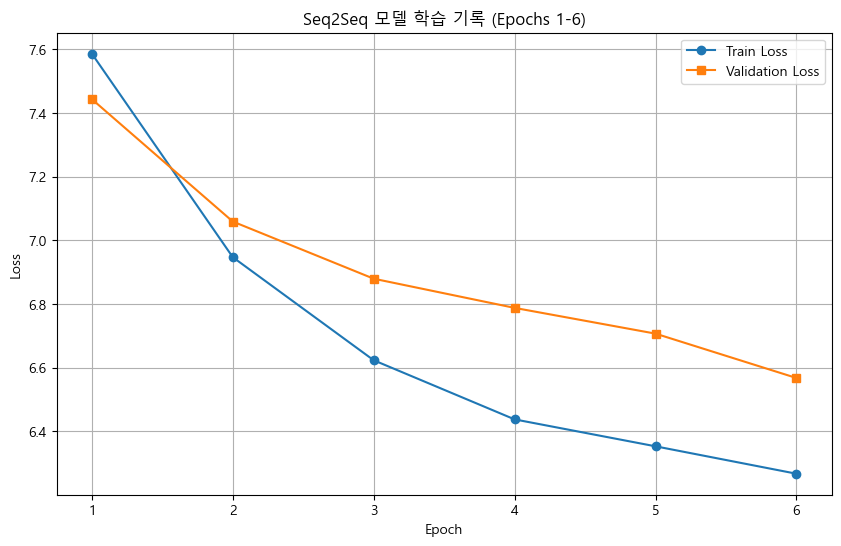

In [30]:
import torch
import matplotlib.pyplot as plt
import os

print("--- 학습 과정 시각화 시작 (Epoch 1-6) ---")

# 1. 시각화할 체크포인트 경로
CHECKPOINT_PATH = 'model/Seq2Seq_checkpoint_epoch_6.pt'

if os.path.exists(CHECKPOINT_PATH):
    print(f"✓ 체크포인트 발견: {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=torch.device('cpu'))
    
    # 2. Loss 기록 추출
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])
    
    if train_losses and val_losses:
        print(f"✓ 총 {len(train_losses)} 에포크의 학습 기록을 로드했습니다.")
        
        # 3. Matplotlib으로 그래프 그리기
        plt.figure(figsize=(10, 6))
        # 이전에 설정한 한글 폰트를 사용합니다.
        set_korean_font() 
        
        plt.plot(train_losses, label='Train Loss', marker='o')
        plt.plot(val_losses, label='Validation Loss', marker='s')
        
        # x축 레이블을 1부터 시작하도록 설정
        epoch_ticks = range(1, len(train_losses) + 1)
        plt.xticks(range(len(train_losses)), epoch_ticks)
        
        plt.title("Seq2Seq 모델 학습 기록 (Epochs 1-6)")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("✗ 오류: 체크포인트에 'train_losses' 또는 'val_losses' 기록이 없습니다.")

else:
    print(f"✗ 오류: 체크포인트 파일을 찾을 수 없습니다. 경로를 확인하세요: {CHECKPOINT_PATH}")

Epoch 6 모델을 불러와 검증 데이터셋(`val_pairs`)의 5개 샘플에 대한 번역 결과를 직접 확인합니다.

(원문, 정답, 모델 번역 비교)

In [37]:
## 2. 번역 결과 확인 (5개 샘플)

import torch
import torch.nn as nn
import os

print("--- 번역 결과 확인 시작 (Epoch 6 모델) ---")

# 1. 모델 인스턴스 생성 및 체크포인트 로드
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
try:
    INPUT_DIM = ko_vocab.n_words
    OUTPUT_DIM = en_vocab.n_words
    EMBEDDING_DIM = 256
    HIDDEN_DIM = 512

    encoder_trans = Encoder(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
    decoder_trans = Decoder(OUTPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM).to(device)
    model_trans = Seq2Seq(encoder_trans, decoder_trans, device).to(device)
    model_trans.eval() # 반드시 평가 모드로 설정

    CHECKPOINT_PATH = 'model/Seq2Seq_checkpoint_epoch_6.pt'

    if os.path.exists(CHECKPOINT_PATH):
        print(f"✓ 체크포인트 로드: {CHECKPOINT_PATH}")
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
        model_trans.load_state_dict(checkpoint['model_state_dict'])
        
        # 2. 검증 데이터 5개 샘플 확인
        for i in range(5):
            src_tokens, ref_tokens = val_pairs[i]
            src_sentence = " ".join(src_tokens)
            ref_sentence = " ".join(ref_tokens)
            
            # 3. 모델 번역 실행
            with torch.no_grad():
                src_indices = [ko_vocab.word2idx.get(word, UNK_TOKEN) for word in src_tokens]
                # SOS, EOS 토큰 추가
                src_indices = [SOS_TOKEN] + src_indices + [EOS_TOKEN]
                src_tensor = torch.LongTensor(src_indices).unsqueeze(0).to(device)
                src_length = torch.LongTensor([len(src_indices)])

                # translate 함수는 이전에 정의된 것을 사용합니다.
                pred_ids = translate(model_trans, src_tensor, src_length)
                pred_tokens = [en_vocab.idx2word[idx] for idx in pred_ids]
                pred_sentence = " ".join(pred_tokens)

            print("\n" + "="*50)
            print(f"샘플 #{i+1}")
            print(f"  - 원문 (SRC): {src_sentence}")
            print(f"  - 정답 (REF): {ref_sentence}")
            print(f"  - 모델 번역 (PRED): {pred_sentence}")
        print("="*50)

    else:
        print(f"✗ 오류: 체크포인트 파일을 찾을 수 없습니다: {CHECKPOINT_PATH}")

except NameError as e:
    print(f"✗ 실행 오류: 필요한 변수나 함수({e})가 정의되지 않았습니다. 이전 셀들을 먼저 실행해주세요.")


--- 번역 결과 확인 시작 (Epoch 6 모델) ---
✓ 체크포인트 로드: model/Seq2Seq_checkpoint_epoch_6.pt

샘플 #1
  - 원문 (SRC): 본래는 서비스 개발만 했지만 , 이번에는 데스크탑 앱도 다루게 되었어요 .
  - 정답 (REF): originally , we only developed services , but this time we're also dealing with desktop apps .
  - 모델 번역 (PRED): it , , , , , it is a .

샘플 #2
  - 원문 (SRC): 일부러 안 웃는 거 맞죠
  - 정답 (REF): you're not laughing on purpose , right ?
  - 모델 번역 (PRED): i you have to you .

샘플 #3
  - 원문 (SRC): 저는 귀하의 컵 브랜드에 매우 관심이 있습니다 .
  - 정답 (REF): i'm very interested in your cup brand .
  - 모델 번역 (PRED): we are interested .

샘플 #4
  - 원문 (SRC): AAA .
  - 정답 (REF): aaa .
  - 모델 번역 (PRED): it's .

샘플 #5
  - 원문 (SRC): 드시고 싶으시면 저희 직원을 불러 주문을 해 주시면 테이블로 갖다 드리겠습니다 .
  - 정답 (REF): if you want to eat , please call our staff and order and we'll bring it to the table .
  - 모델 번역 (PRED): we are you for your company .


모델 번역이 엉망입니다.

BLEU 가 0점 나올것 같지만 우선은 진행해보겠습니다.

BLEU score 진행 과정

```csss
Seq2Seq (no attention)
→ BLEU 측정 (baseline)
→ Attention Seq2Seq
→ BLEU 재측정
→ 비교 분석
```

In [28]:
# 8. BLEU 계산 함수

import nltk
from nltk.translate.bleu_score import corpus_bleu
def evaluate_bleu(model, dataloader, ko_vocab, en_vocab, device):
    # 1. 모델을 평가 모드로 전환
    model.eval()

    # 2. 평가에 사용할 리스트 초기화
    references = [] # 실제 정답 문장들 (리스트의 리스트)
    candidates = [] # 모델이 생성한 번역 문장들

    # 3. 그래디언트 계산 비활성화
    with torch.no_grad():
        # dataloader 에서 배치 단위로 데이터를 가져옴
        for src, src_lengths, trg in dataloader:
            src = src.to(device)
            trg = trg.to(device)
            
            # 배치 내 각 문장 처리
            for i in range(src.size(0)):
                # 번역 수행
                pred_ids = translate(
                    model,
                    src[i].unsqueeze(0),
                    [src_lengths[i]]
                )
                
                # 예측 토큰을 단어로 변환
                pred_tokens = [
                    en_vocab.idx2word[idx] for idx in pred_ids
                ]
                
                # 정답 토큰을 단어로 변환(특수 토큰 제외)
                true_tokens = [
                    en_vocab.idx2word[idx.item()]
                    for idx in trg[i]
                    if idx not in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]
                ]
                
                # 수집
                candidates.append(pred_tokens)
                references.append([true_tokens]) # 다중 참조 지원을 위한 리스트로 감싸기
    
    bleu_score = corpus_bleu(references, candidates)
        
    return bleu_score


In [30]:
from torch.utils.data import Subset, DataLoader
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import random
import time

# BLEU 전용 RNG (전역 1회 생성 권장)
bleu_rng = random.Random()
bleu_rng.seed(time.time())

def evaluate_bleu_random_subset(
    model,
    dataset,
    ko_vocab,
    en_vocab,
    device,
    sample_size=10
):
    model.eval()

    indices = bleu_rng.sample(range(len(dataset)), sample_size)
    subset = Subset(dataset, indices)
    loader = DataLoader(subset,
                        batch_size=1,
                        shuffle=False,
                        collate_fn=collate_fn)

    references = []
    candidates = []

    smooth = SmoothingFunction().method1

    with torch.no_grad():
        for src, src_lengths, trg in loader:
            src = src.to(device)
            trg = trg.to(device)

            pred_ids = translate(
                model,
                src,
                src_lengths   # CPU 유지 권장
            )

            # 예측 토큰 처리 (특수 토큰 제거)
            pred_tokens = [
                en_vocab.idx2word[idx]
                for idx in pred_ids
                if idx not in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]
            ]

            # 정답 토큰 처리
            true_tokens = [
                en_vocab.idx2word[idx.item()]
                for idx in trg[0]
                if idx not in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]
            ]

            candidates.append(pred_tokens)
            references.append([true_tokens])

    bleu_score = corpus_bleu(
        references,
        candidates,
        smoothing_function=smooth
    )

    return bleu_score

In [34]:
# 1. 모델 구조 생성
encoder = Encoder(ko_vocab.n_words, EMBEDDING_DIM, HIDDEN_DIM).to(device)
decoder = Decoder(en_vocab.n_words, EMBEDDING_DIM, HIDDEN_DIM).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)

# 2. 체크포인트에서 가중치 로드
checkpoint = torch.load('model/Seq2Seq_checkpoint_epoch_6.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

# 3. 평가
bleu_score = evaluate_bleu_random_subset(
    model=model,  # 가중치 로드된 모델
    dataset=val_dataset,
    ko_vocab=ko_vocab,
    en_vocab=en_vocab,
    device=device,
    sample_size=50
)

print(f"BLUE score : {bleu_score}")

BLUE score : 0.03946641714662153


BLEU score 는 0.0394 점으로 나왔고, 낮은 점수로 여겨지는  원인은

1) 적은 epoch (과적합이 아니지만 환경 상 더이상 학습 불가)
2) Attention 없음 (긴 문장에서 정보 손실)
3) 데이터 샘플링 (25% 만 학습하여 학습량 부족)

으로 생각합니다.

**기존 Decoder (No Attention)**

- 입력: 이전 단어 + hidden
- 정보 출처: Encoder 마지막 hidden 하나
- 한계: 긴 문장에서 앞부분 정보 소실 (정보 병목 현상)

개선 및 비교를 위해 Attention Decoder 클래스를 선언합니다.

**Attention Decoder**

- 입력: 이전 단어 + hidden
- 정보 출처:
    - Encoder의 모든 출력 (outputs)
    - 현재 Decoder hidden

- 장점: 번역 시점마다 입력 문장의 중요한 부분을 선택

**Attention 메커니즘 (Bahdanau 방식)**

- **Query**: Decoder의 현재 hidden state
- **Key/Value**: Encoder의 모든 outputs (각 시점의 hidden states)
- **Process**: 
  1. Alignment score 계산<br/> (Query와 각 Key의 유사도)
  2. Softmax로 attention weights 생성 (합=1)
  3. Weights를 이용해 Value의 가중합 계산
- **Return**: Context vector (입력 문장의 중요 정보를 담은 가중합 벡터)

#### Attention 클래스 선언

In [35]:
import torch.nn as nn

class Attention(nn.Module):
    """
    Bahdanau Attention: Decoder가 Encoder의 어느 부분을 봐야 하는지 계산
    """
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        
        # [Query; Key] → Alignment score
        self.W_align = nn.Linear(hidden_dim * 2, hidden_dim)
        
        # Alignment → Scalar score
        self.W_score = nn.Linear(hidden_dim, 1, bias=False)
        
    def forward(self, query, memory):
        """
        Args:
            query: Decoder의 현재 상태 (batch, hidden_dim)
            memory: Encoder의 모든 상태 (batch, seq_len, hidden_dim)
        
        Returns:
            weights: 각 입력 위치에 대한 가중치 (batch, seq_len)
        """
        # Query를 memory 길이만큼 복제
        query_expanded = query.unsqueeze(1).expand_as(memory)
        
        # 1. Query와 Memory 결합
        combined = torch.cat([query_expanded, memory], dim=-1)
        
        # 2. Alignment 계산 (유사도)
        alignment = torch.tanh(self.W_align(combined))
        
        # 3. Score 계산
        scores = self.W_score(alignment).squeeze(-1)
        
        # 4. 확률 분포로 변환
        weights = torch.softmax(scores, dim=-1)
        
        return weights

In [36]:
class DecoderWithAttention(nn.Module):
    """
    Attention 메커니즘을 사용하는 Decoder
    """
    def __init__(self, output_size, embedding_dim, hidden_dim, n_layers=1, dropout=0.5):
        """
        Args:
            output_size (int): 출력 어휘 사전 크기 (en_vocab.n_words)
            embedding_dim (int): 임베딩 차원 (Encoder와 동일)
            hidden_dim (int): 은닉 상태 차원 (Encoder와 동일)
            n_layers (int): RNN 레이어 수 (Encoder와 동일)
            dropout (float): 과적합 방지 비율
        """
        super(DecoderWithAttention, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        
        # 임베딩 레이어
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=PAD_TOKEN)
        
        # Attention 레이어
        self.attention = Attention(hidden_dim)
        
        # GRU 레이어 (입력: embedding + context vector)
        self.gru = nn.GRU(
            embedding_dim + hidden_dim,  # 임베딩 + context vector
            hidden_dim,
            n_layers,
            dropout=(0 if n_layers == 1 else dropout),
            batch_first=True
        )
        
        # 출력 레이어
        self.fc_out = nn.Linear(hidden_dim, output_size)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, input_token, hidden, encoder_outputs):
        """
        Args:
            input_token: 현재 시점의 입력 토큰 (batch, 1)
            hidden: 이전 시점의 은닉 상태 (n_layers, batch, hidden_dim)
            encoder_outputs: Encoder의 모든 출력 (batch, seq_len, hidden_dim)
        
        Returns:
            output: 예측 분포 (batch, 1, output_size)
            hidden: 현재 시점의 은닉 상태 (n_layers, batch, hidden_dim)
            attention_weights: Attention 가중치 (batch, seq_len)
        """
        # 1. 임베딩
        embedded = self.dropout(self.embedding(input_token))  # (batch, 1, embedding_dim)
        
        # 2. Attention 계산 (마지막 레이어의 hidden state 사용)
        query = hidden[-1]  # (batch, hidden_dim)
        attention_weights = self.attention(query, encoder_outputs)  # (batch, seq_len)
        
        # 3. Context vector 계산 (가중합)
        context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs)  # (batch, 1, hidden_dim)
        
        # 4. 임베딩과 context 결합
        gru_input = torch.cat([embedded, context], dim=-1)  # (batch, 1, embedding_dim + hidden_dim)
        
        # 5. GRU 통과
        output, hidden = self.gru(gru_input, hidden)
        
        # 6. 최종 출력
        output = self.fc_out(output)  # (batch, 1, output_size)
        
        return output, hidden, attention_weights

In [37]:
# ============================================================
# 1. Seq2Seq forward 수정 - attention_weights 저장 중단
# ============================================================
class Seq2SeqWithAttention(nn.Module):
    """
    Attention 메커니즘을 사용하는 Seq2Seq 모델
    """
    def __init__(self, encoder, decoder):
        super(Seq2SeqWithAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
    
    def forward(self, src_seqs, src_lengths, trg_seqs, teacher_forcing_ratio=0.5):
        """
        Args:
            src_seqs: 입력 시퀀스 (batch, src_seq_len)
            src_lengths: 입력 시퀀스 실제 길이
            trg_seqs: 타겟 시퀀스 (batch, trg_seq_len)
            teacher_forcing_ratio: Teacher Forcing 비율
        
        Returns:
            outputs: 예측 결과 (batch, trg_seq_len, output_size)
        """
        batch_size = src_seqs.size(0)
        trg_seq_len = trg_seqs.size(1)
        trg_vocab_size = self.decoder.fc_out.out_features
        
        # 출력 저장 텐서
        outputs = torch.zeros(batch_size, trg_seq_len, trg_vocab_size).to(device)
        
        # attention_weights_list 제거! - 메모리 누수의 주범
        
        # 1. Encoder 통과
        encoder_outputs, hidden = self.encoder(src_seqs, src_lengths)
        
        # 2. Decoder 시작 토큰
        decoder_input = trg_seqs[:, 0].unsqueeze(1)
        
        # 3. Decoder 반복
        for t in range(1, trg_seq_len):
            # Decoder 한 스텝
            output, hidden, attention_weights = self.decoder(
                decoder_input, hidden, encoder_outputs
            )
            
            # attention_weights는 즉시 버림 (저장 안함)
            
            # 결과 저장
            outputs[:, t, :] = output.squeeze(1)
            
            # Teacher Forcing 결정
            teacher_force = random.random() < teacher_forcing_ratio
            
            # 다음 입력 결정
            if teacher_force:
                decoder_input = trg_seqs[:, t].unsqueeze(1)
            else:
                decoder_input = output.argmax(dim=-1)
        
        return outputs  # attention_weights_list 반환 안함

In [38]:
# 4. 모델 인스턴스 생성
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

INPUT_DIM = ko_vocab.n_words # 한국어 어휘 사전
OUTPUT_DIM = en_vocab.n_words # 영어 어휘 사전
EMBEDDING_DIM = 256 # 임베딩 차원
HIDDEN_DIM = 512 # Hidden 차원
N_LAYERS = 1 # RNN 레이어 수
DROPOUT = 0.5 # 드롭아웃 비율

# Attention을 사용하는 모델 생성
encoder_with_attention = Encoder(
    input_size=ko_vocab.n_words,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT
).to(device)

decoder_with_attention = DecoderWithAttention(
    output_size=en_vocab.n_words,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT
).to(device)

attention_model = Seq2SeqWithAttention(encoder_with_attention, decoder_with_attention).to(device)

print("=" * 60)
print("Attention 모델 생성 완료!")
print("=" * 60)
print(f"Encoder 파라미터 수: {sum(p.numel() for p in encoder_with_attention.parameters()):,}")
print(f"Decoder 파라미터 수: {sum(p.numel() for p in decoder_with_attention.parameters()):,}")
print(f"전체 파라미터 수: {sum(p.numel() for p in attention_model.parameters()):,}")
print("=" * 60)

Attention 모델 생성 완료!
Encoder 파라미터 수: 70,776,320
Decoder 파라미터 수: 40,014,743
전체 파라미터 수: 110,791,063


## 모델 학습
모델 학습을 진행하겠습니다.

In [23]:
# ============================================================
# 2. 학습 함수 수정 - 메모리 정리 추가
# ============================================================
def train_epoch_attention(model, dataloader, optimizer, criterion, device):
    """
    Attention 모델 학습 함수 - 메모리 누수 방지
    """
    model.train()
    epoch_loss = 0
    
    progress_bar = tqdm(dataloader, desc="Training")
    
    for batch_idx, (src, src_lengths, trg) in enumerate(progress_bar):
        src = src.to(device)
        trg = trg.to(device)
        
        optimizer.zero_grad()
        
        # Forward
        output = model(src, src_lengths, trg)  # 이제 하나만 반환
        
        # Loss 계산
        output = output[:, 1:].reshape(-1, output.size(-1))
        trg = trg[:, 1:].reshape(-1)
        
        loss = criterion(output, trg)
        loss.backward()
        
        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        # 주기적으로 메모리 캐시 비우기 (50 배치마다)
        if batch_idx % 50 == 0:
            torch.cuda.empty_cache()
        
    return epoch_loss / len(dataloader)

In [24]:
def evaluate_epoch_attention(model, dataloader, criterion, device):
    """
    Attention 모델 평가 함수 - 메모리 누수 방지
    """
    model.eval()
    epoch_loss = 0
    
    progress_bar = tqdm(dataloader, desc="Validation")
    
    with torch.no_grad():
        for batch_idx, (src, src_lengths, trg) in enumerate(progress_bar):
            src = src.to(device)
            trg = trg.to(device)
            
            # Teacher forcing ratio = 0
            output = model(src, src_lengths, trg, teacher_forcing_ratio=0)
            
            output = output[:, 1:].reshape(-1, output.size(-1))
            trg = trg[:, 1:].reshape(-1)
            
            loss = criterion(output, trg)
            epoch_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
            
            # 주기적으로 메모리 캐시 비우기
            if batch_idx % 50 == 0:
                torch.cuda.empty_cache()
            
    return epoch_loss / len(dataloader)

In [25]:
# ============================================================
# 3. Early Stopping 함수 수정 - epoch마다 메모리 정리
# ============================================================
from tqdm import tqdm
def train_with_early_stopping_attention(
    model, 
    train_loader, 
    val_loader,
    optimizer, 
    criterion, 
    device,
    num_epochs=50,
    patience=5,
    min_delta=1e-4,
    save_every=1,
    model_name='attention_model'
):
    """
    Attention 모델용 Early Stopping 학습 함수 - 메모리 누수 방지
    """
    
    import os
    os.makedirs('model', exist_ok=True)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_path = None
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        print(f'\n{"="*60}')
        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'{"="*60}')
        
        # 학습
        train_loss = train_epoch_attention(model, train_loader, optimizer, criterion, device)
        
        # Epoch 종료 후 메모리 정리
        torch.cuda.empty_cache()
        
        # 검증
        val_loss = evaluate_epoch_attention(model, val_loader, criterion, device)
        
        # Epoch 종료 후 메모리 정리
        torch.cuda.empty_cache()
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        # 현재 메모리 사용량 출력
        if torch.cuda.is_available():
            allocated = torch.cuda.memory_allocated(0) / 1024**3
            reserved = torch.cuda.memory_reserved(0) / 1024**3
            print(f'GPU 메모리: {allocated:.2f} GB allocated, {reserved:.2f} GB reserved')
        
        # 결과 출력
        print(f'\nTrain Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Best Val Loss: {best_val_loss:.4f}')
        
        # 주기적 체크포인트 저장
        if (epoch + 1) % save_every == 0:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
            }
            checkpoint_path = f'model/{model_name}_epoch_{epoch+1}.pt'
            torch.save(checkpoint, checkpoint_path)
            print(f'체크포인트 저장: {checkpoint_path}')
        
        # Early Stopping 체크
        if val_loss < best_val_loss - min_delta:
            print(f'검증 손실 개선: {best_val_loss:.4f} → {val_loss:.4f}')
            best_val_loss = val_loss
            patience_counter = 0
            
            # 최고 성능 모델 저장
            if best_path and os.path.exists(best_path):
                os.remove(best_path)
            
            best_path = f'model/{model_name}_best.pt'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
            }, best_path)
            print(f'최고 성능 모델 저장: {best_path}')
        else:
            patience_counter += 1
            print(f'개선 없음: {patience_counter} epoch(s)')
            
            if patience_counter >= patience:
                print(f'\n{"="*60}')
                print(f'Early stopping! ({patience} epochs 동안 개선 없음)')
                print(f'{"="*60}')
                break
    
    print(f'\n{"="*60}')
    print('학습 완료!')
    print(f'최고 검증 손실: {best_val_loss:.4f}')
    print(f'최고 모델 경로: {best_path}')
    print(f'{"="*60}')
    
    return train_losses, val_losses, best_path

In [26]:
# ============================================================
# 4. Optimizer와 Criterion 설정
# ============================================================
import torch.optim as optim

# Optimizer 설정
attention_optimizer = optim.Adam(attention_model.parameters(), lr=0.001)

# Loss Function 설정 (패딩 토큰 무시)
attention_criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)

print("=" * 60)
print("Attention 모델 학습 준비 완료!")
print("=" * 60)
print(f"Optimizer: Adam (lr=0.001)")
print(f"Criterion: CrossEntropyLoss (ignore_index={PAD_TOKEN})")
print("=" * 60)

Attention 모델 학습 준비 완료!
Optimizer: Adam (lr=0.001)
Criterion: CrossEntropyLoss (ignore_index=2)


In [47]:
# GPU 메모리 정리
import gc
import torch

# 기존 모델들 삭제
if 'seq2seq_model' in globals():
    del seq2seq_model
if 'encoder' in globals():
    del encoder
if 'decoder' in globals():
    del decoder

# 가비지 컬렉션
gc.collect()

# CUDA 캐시 비우기
torch.cuda.empty_cache()

print("GPU 메모리 정리 완료!")
print(f"현재 GPU 메모리 사용량: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
print(f"예약된 GPU 메모리: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

GPU 메모리 정리 완료!
현재 GPU 메모리 사용량: 8.74 GB
예약된 GPU 메모리: 10.89 GB


In [ ]:
# ============================================================
# 5. 학습 시작
# ============================================================
# 학습 실행 (예시)
train_losses, val_losses, best_model_path = train_with_early_stopping_attention(
    model=attention_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=attention_optimizer,
    criterion=attention_criterion,
    device=device,
    num_epochs=15,
    patience=5,
    min_delta=1e-4,
    save_every=5,
    model_name='attention_model'
)

```text
============================================================
Epoch 1/15
============================================================
Training: 100%|██████████| 9375/9375 [58:17<00:00,  2.68it/s, loss=4.6520]   
Validation: 100%|██████████| 2344/2344 [03:44<00:00, 10.42it/s, loss=5.2087]
GPU 메모리: 1.68 GB allocated, 2.09 GB reserved

Train Loss: 4.9852 | Val Loss: 5.3426 | Best Val Loss: inf
검증 손실 개선: inf → 5.3426
최고 성능 모델 저장: model/attention_model_best.pt

============================================================
Epoch 2/15
============================================================
Training: 100%|██████████| 9375/9375 [52:34<00:00,  2.97it/s, loss=4.8332]  
Validation: 100%|██████████| 2344/2344 [03:24<00:00, 11.49it/s, loss=5.0349]
GPU 메모리: 1.68 GB allocated, 2.39 GB reserved

Train Loss: 4.4948 | Val Loss: 5.1709 | Best Val Loss: 5.3426
검증 손실 개선: 5.3426 → 5.1709
최고 성능 모델 저장: model/attention_model_best.pt

============================================================
Epoch 3/15
============================================================
Training: 100%|██████████| 9375/9375 [1:00:12<00:00,  2.60it/s, loss=4.0724]
Validation: 100%|██████████| 2344/2344 [03:32<00:00, 11.03it/s, loss=4.7420]
GPU 메모리: 1.68 GB allocated, 2.28 GB reserved

Train Loss: 4.2805 | Val Loss: 5.0983 | Best Val Loss: 5.1709
검증 손실 개선: 5.1709 → 5.0983
최고 성능 모델 저장: model/attention_model_best.pt

============================================================
Epoch 4/15
============================================================
Training: 100%|██████████| 9375/9375 [59:55<00:00,  2.61it/s, loss=4.4959]  
Validation: 100%|██████████| 2344/2344 [03:46<00:00, 10.36it/s, loss=4.7596]
GPU 메모리: 1.68 GB allocated, 2.08 GB reserved

Train Loss: 4.1324 | Val Loss: 4.9825 | Best Val Loss: 5.0983
검증 손실 개선: 5.0983 → 4.9825
최고 성능 모델 저장: model/attention_model_best.pt

============================================================
Epoch 5/15
============================================================
Training: 100%|██████████| 9375/9375 [59:58<00:00,  2.61it/s, loss=4.0792]  
Validation: 100%|██████████| 2344/2344 [03:29<00:00, 11.20it/s, loss=4.7823]
GPU 메모리: 1.68 GB allocated, 2.07 GB reserved

Train Loss: 4.0051 | Val Loss: 4.9814 | Best Val Loss: 4.9825
체크포인트 저장: model/attention_model_epoch_5.pt
검증 손실 개선: 4.9825 → 4.9814
최고 성능 모델 저장: model/attention_model_best.pt

============================================================
Epoch 6/15
============================================================
Training: 100%|██████████| 9375/9375 [59:52<00:00,  2.61it/s, loss=4.0240]   
Validation: 100%|██████████| 2344/2344 [04:12<00:00,  9.29it/s, loss=4.7060]
GPU 메모리: 1.68 GB allocated, 2.32 GB reserved

Train Loss: 3.9010 | Val Loss: 4.9464 | Best Val Loss: 4.9814
검증 손실 개선: 4.9814 → 4.9464
최고 성능 모델 저장: model/attention_model_best.pt

============================================================
Epoch 7/15
============================================================
Training: 100%|██████████| 9375/9375 [1:02:17<00:00,  2.51it/s, loss=3.8784] 
Validation: 100%|██████████| 2344/2344 [04:25<00:00,  8.83it/s, loss=4.8990]
GPU 메모리: 1.68 GB allocated, 2.07 GB reserved

Train Loss: 3.8200 | Val Loss: 4.9328 | Best Val Loss: 4.9464
검증 손실 개선: 4.9464 → 4.9328
최고 성능 모델 저장: model/attention_model_best.pt

============================================================
Epoch 8/15
============================================================
Training: 100%|██████████| 9375/9375 [1:05:10<00:00,  2.40it/s, loss=3.8517]
Validation: 100%|██████████| 2344/2344 [03:29<00:00, 11.18it/s, loss=4.3357]
GPU 메모리: 1.68 GB allocated, 2.09 GB reserved

Train Loss: 3.7436 | Val Loss: 4.8597 | Best Val Loss: 4.9328
검증 손실 개선: 4.9328 → 4.8597
최고 성능 모델 저장: model/attention_model_best.pt

============================================================
Epoch 9/15
============================================================
Training: 100%|██████████| 9375/9375 [52:44<00:00,  2.96it/s, loss=2.7954]  
Validation: 100%|██████████| 2344/2344 [03:30<00:00, 11.16it/s, loss=4.6315]
GPU 메모리: 1.68 GB allocated, 2.10 GB reserved

Train Loss: 3.6708 | Val Loss: 4.8564 | Best Val Loss: 4.8597
검증 손실 개선: 4.8597 → 4.8564
최고 성능 모델 저장: model/attention_model_best.pt

============================================================
Epoch 10/15
============================================================
Training: 100%|██████████| 9375/9375 [50:32<00:00,  3.09it/s, loss=3.8083]   
Validation: 100%|██████████| 2344/2344 [03:23<00:00, 11.52it/s, loss=4.3811]
GPU 메모리: 1.68 GB allocated, 2.22 GB reserved

Train Loss: 3.6136 | Val Loss: 4.8406 | Best Val Loss: 4.8564
체크포인트 저장: model/attention_model_epoch_10.pt
검증 손실 개선: 4.8564 → 4.8406
최고 성능 모델 저장: model/attention_model_best.pt

============================================================
Epoch 11/15
============================================================
Training: 100%|██████████| 9375/9375 [49:43<00:00,  3.14it/s, loss=3.2716]  
Validation: 100%|██████████| 2344/2344 [03:10<00:00, 12.30it/s, loss=4.5297]
GPU 메모리: 1.68 GB allocated, 2.21 GB reserved

Train Loss: 3.5573 | Val Loss: 4.8334 | Best Val Loss: 4.8406
검증 손실 개선: 4.8406 → 4.8334
최고 성능 모델 저장: model/attention_model_best.pt

============================================================
Epoch 12/15
============================================================
Training: 100%|██████████| 9375/9375 [48:41<00:00,  3.21it/s, loss=3.7324]   
Validation: 100%|██████████| 2344/2344 [03:14<00:00, 12.02it/s, loss=4.3247]
GPU 메모리: 1.68 GB allocated, 2.38 GB reserved

Train Loss: 3.5076 | Val Loss: 4.8242 | Best Val Loss: 4.8334
검증 손실 개선: 4.8334 → 4.8242
최고 성능 모델 저장: model/attention_model_best.pt

============================================================
Epoch 13/15
============================================================
Training: 100%|██████████| 9375/9375 [49:31<00:00,  3.16it/s, loss=3.2580]  
Validation: 100%|██████████| 2344/2344 [03:07<00:00, 12.49it/s, loss=4.2110]
GPU 메모리: 1.68 GB allocated, 2.41 GB reserved

Train Loss: 3.4649 | Val Loss: 4.8149 | Best Val Loss: 4.8242
검증 손실 개선: 4.8242 → 4.8149
최고 성능 모델 저장: model/attention_model_best.pt

============================================================
Epoch 14/15
============================================================
Training: 100%|██████████| 9375/9375 [48:58<00:00,  3.19it/s, loss=3.4362]  
Validation: 100%|██████████| 2344/2344 [03:13<00:00, 12.10it/s, loss=4.2586]
GPU 메모리: 1.68 GB allocated, 2.08 GB reserved

Train Loss: 3.4217 | Val Loss: 4.8281 | Best Val Loss: 4.8149
개선 없음: 1 epoch(s)

============================================================
Epoch 15/15
============================================================
Training:   1%|          | 84/9375 [00:41<1:16:50,  2.02it/s, loss=3.6349]
```

여기까지만 하고 학습을 멈췄습니다.

In [44]:
def translate_attention(model, src, src_lengths, max_len=50):
    model.eval()
    
    with torch.no_grad():
        # encoder 출력
        encoder_outputs, hidden = model.encoder(src, src_lengths)
        
         # (batch, 1) 형태로 변경
        input_token = torch.tensor([[SOS_TOKEN]]).to(src.device)
        
        result = []
        
        for _ in range(max_len):
            # Attention 디코더는 encoder_outputs 필요
            output, hidden, _ = model.decoder(input_token, hidden, encoder_outputs)
             # output shape: (batch, 1, vocab_size) → argmax
            top1 = output.argmax(2).squeeze(1)  # (batch,)
            
            if top1.item() == EOS_TOKEN:
                break
            
            result.append(top1.item())
             # 다음 입력도 (batch, 1) 형태 유지
            input_token = top1.unsqueeze(1)  # (batch, 1)
    
    return result


In [45]:
# 체크포인트 로드
checkpoint = torch.load('model/attention_model_best.pt', map_location=device)

# 모델 생성 및 가중치 로드
encoder_attn = Encoder(ko_vocab.n_words, EMBEDDING_DIM, HIDDEN_DIM).to(device)
decoder_attn = DecoderWithAttention(en_vocab.n_words, EMBEDDING_DIM, HIDDEN_DIM).to(device)
attention_model = Seq2SeqWithAttention(encoder_attn, decoder_attn)
attention_model.load_state_dict(checkpoint['model_state_dict'])
attention_model.eval()  # 평가 모드 설정

for i in range(5):
    # 원본 데이터 가져오기
    src_tokens = val_pairs[i][0]
    ref_tokens = val_pairs[i][1]
    
    src_sentence = " ".join(src_tokens)
    ref_sentence = " ".join(ref_tokens)
    
    # 한국어 문장을 텐서로 변환
    src_indices = [ko_vocab.word2idx.get(word, UNK_TOKEN) for word in src_tokens]
    src_tensor = torch.tensor(src_indices).unsqueeze(0).to(device)
    src_length = [len(src_indices)]
    
    # 모델을 통해 번역 (translate_attention 함수 사용)
    pred_ids = translate_attention(
        model=attention_model,
        src=src_tensor,
        src_lengths=src_length
    )
    
    # 예측 결과를 단어로 변환
    pred_tokens = [en_vocab.idx2word[idx] for idx in pred_ids]
    pred_sentence = " ".join(pred_tokens)
    
    print("----------------------------------------------------")
    print(f"예제 {i+1}")
    print(f"원문 (SRC): {src_sentence}")
    print(f"정답 (REF): {ref_sentence}")
    print(f"모델 번역 (PRED): {pred_sentence}")
    print("----------------------------------------------------")

----------------------------------------------------
예제 1
원문 (SRC): 본래는 서비스 개발만 했지만 , 이번에는 데스크탑 앱도 다루게 되었어요 .
정답 (REF): originally , we only developed services , but this time we're also dealing with desktop apps .
모델 번역 (PRED): with your time , the the of the the the the time , the the the time , the the the time , the the the time , the the the time , the the the time , the the the the the time , the the the the the
----------------------------------------------------
----------------------------------------------------
예제 2
원문 (SRC): 일부러 안 웃는 거 맞죠
정답 (REF): you're not laughing on purpose , right ?
모델 번역 (PRED): you can
----------------------------------------------------
----------------------------------------------------
예제 3
원문 (SRC): 저는 귀하의 컵 브랜드에 매우 관심이 있습니다 .
정답 (REF): i'm very interested in your cup brand .
모델 번역 (PRED): i'm very interested in your brand brand brand brand in your brand brand brand brand your brand and your brand your brand and your brand and very very very ve

In [47]:
import torch
import matplotlib.pyplot as plt
import os

print("--- 학습 과정 시각화 시작 (Epoch 1-10) ---")

# 1. 시각화할 체크포인트 경로
CHECKPOINT_PATH = 'model/attention_model_best.pt'

if os.path.exists(CHECKPOINT_PATH):
    print(f"✓ 체크포인트 발견: {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=torch.device('cpu'))
    
    # 2. Loss 기록 추출
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])
    
    if train_losses and val_losses:
        print(f"✓ 총 {len(train_losses)} 에포크의 학습 기록을 로드했습니다.")
        
        # 3. Matplotlib으로 그래프 그리기
        plt.figure(figsize=(10, 6))
        # 이전에 설정한 한글 폰트를 사용합니다.
        set_korean_font() 
        
        plt.plot(train_losses, label='Train Loss', marker='o')
        plt.plot(val_losses, label='Validation Loss', marker='s')
        
        # x축 레이블을 1부터 시작하도록 설정
        epoch_ticks = range(1, len(train_losses) + 1)
        plt.xticks(range(len(train_losses)), epoch_ticks)
        
        plt.title("Attention 모델 학습 기록 (Epochs 1-10)")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("✗ 오류: 체크포인트에 'train_losses' 또는 'val_losses' 기록이 없습니다.")

else:
    print(f"✗ 오류: 체크포인트 파일을 찾을 수 없습니다. 경로를 확인하세요: {CHECKPOINT_PATH}")

--- 학습 과정 시각화 시작 (Epoch 1-10) ---
✓ 체크포인트 발견: model/attention_model_best.pt
✗ 오류: 체크포인트에 'train_losses' 또는 'val_losses' 기록이 없습니다.


In [49]:
def evaluate_bleu_attention(
    model,
    dataset,
    ko_vocab,
    en_vocab,
    device,
    sample_size=10
):
    model.eval()

    indices = bleu_rng.sample(range(len(dataset)), sample_size)
    subset = Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=1, shuffle=False, collate_fn=collate_fn)

    references = []
    candidates = []

    smooth = SmoothingFunction().method1

    with torch.no_grad():
        for src, src_lengths, trg in loader:
            src = src.to(device)
            trg = trg.to(device)

            # translate_attention 사용
            pred_ids = translate_attention(
                model,
                src,
                src_lengths
            )

            pred_tokens = [
                en_vocab.idx2word[idx]
                for idx in pred_ids
                if idx not in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]
            ]

            true_tokens = [
                en_vocab.idx2word[idx.item()]
                for idx in trg[0]
                if idx not in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]
            ]

            candidates.append(pred_tokens)
            references.append([true_tokens])

    bleu_score = corpus_bleu(
        references,
        candidates,
        smoothing_function=smooth
    )

    return bleu_score


In [50]:
# 1. 모델 구조 생성 Attention 버전으로 변경
encoder_attn = Encoder(ko_vocab.n_words, EMBEDDING_DIM, HIDDEN_DIM).to(device)
decoder_attn = DecoderWithAttention(en_vocab.n_words, EMBEDDING_DIM, HIDDEN_DIM).to(device)
attention_model = Seq2SeqWithAttention(encoder_attn, decoder_attn).to(device)

# 2. 체크포인트에서 가중치 로드 경로 변경
checkpoint = torch.load('model/attention_model_best.pt', map_location=device)
attention_model.load_state_dict(checkpoint['model_state_dict'])

# 3. 평가 모델 변경
bleu_score = evaluate_bleu_attention(
    model=attention_model,  # attention_model로 변경
    dataset=val_dataset,
    ko_vocab=ko_vocab,
    en_vocab=en_vocab,
    device=device,
    sample_size=50
)

print(f"BLEU score : {bleu_score}")

BLEU score : 0.11626838045784389


## 회고

처음에는 전체 데이터를 사용하여 학습을 진행하려 했으나,

A100 GPU(Colab Pro) 환경에서도 메모리 부족 문제가 발생하여 데이터를 샘플링(25%)하여 학습을 진행하였습니다.

데이터 분할의 필요성을 늦게 인지하여 재학습을 시작한 시점이 늦어졌기에,

Attention 모델의 충분한 학습이 이루어지지 못한 점이 아쉽습니다.

그럼에도 불구하고, 이번 프로젝트를 통해 Seq2Seq 구조의 Encoder-Decoder 아키텍처와 Attention 메커니즘의 원리를 깊이 이해할 수 있었습니다.

향후 충분한 학습 시간과 컴퓨팅 자원을 확보하여 Attention 모델의 성능을 개선해보고 싶습니다.